In [4]:
from qcodes.parameters import MultiParameter
import numpy as np
from qcodes import Parameter
import sys
from time import sleep
import pyvisa
import qcodes as qc
import time
import matplotlib.pyplot as plt

In [5]:
rm = pyvisa.ResourceManager()

In [5]:
from qcodes.dataset import Measurement
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
initialise_or_create_database_at("./2026-02-12_SNSPD2_dark_counts.db")

from time import sleep, monotonic

# Set up experiment
exp_name = 'Dark_counts_12_02_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Experiment loaded. Last ID no: 58


In [7]:
# yoko.close()
from qcodes.instrument_drivers.yokogawa import GS200
yoko = GS200.GS200('yoko', 'TCPIP0::10.196.52.75::inst0::INSTR')

Connected to: YOKOGAWA GS210 (serial:91T928105, firmware:2.02) in 0.30s


In [347]:
# dmm.close()
from qcodes.instrument_drivers.Keysight import Keysight34410A
dmm = Keysight34410A('dmm', 'TCPIP0::10.196.52.73::inst0::INSTR')

Connected to: Agilent Technologies 34410A (serial:MY47027892, firmware:2.35-2.35-0.09-46-09) in 0.11s


In [8]:
from MSO5 import MSO5
# MS.close()
MS = MSO5('MS', address='TCPIP0::10.196.52.93::inst0::INSTR', channels_n =4)


D:\SNSPD\SNSPD2\MSO5.py:5: QCoDeSDeprecationWarning: The `qcodes.instrument.base` module is deprecated. Please consult the api documentation at https://microsoft.github.io/Qcodes/api/index.html for alternatives.
  from qcodes.instrument.base import InstrumentBase


In [10]:
##### SUPERSEDED #####

# def count_rate_two(MS,bin, total):
#     # # Initialisation? 
#     MS.write("SEARCH:SEARCH1:STATE 0")
#     MS.write("SEARCH:SEARCH1:STATE 1")
#     MS.write("SEARCH:SEARCH2:STATE 0")
#     MS.write("SEARCH:SEARCH2:STATE 1")

#     start = time.time()
#     end = start + total

#     counts1= []
#     counts2= []
    
#     #sleep if changing the trigger level
#     #sleep(0.5)
#     while time.time() < end:
#         time.sleep(bin)
#         now = time.time()

#         # Extract counts 
#         count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
#         count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

#         counts1.append(count1)
#         counts2.append(count2)
        
#     end1 = sum(counts1)
#     end2 = sum(counts2)
        
#     return counts1, end1, counts2, end2

In [228]:
import datetime
def count_rate_two(MS,bin_length, n_captures):
    # # Initialisation? 
    MS.write("SEARCH:SEARCH1:STATE 0")
    MS.write("SEARCH:SEARCH1:STATE 1")
    MS.write("SEARCH:SEARCH2:STATE 0")
    MS.write("SEARCH:SEARCH2:STATE 1")

    start = time.perf_counter()
    print(f'This acquisition will take {n_captures*bin_length}s')
    print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

    counts1= []
    counts2= []
    

    
    for i in range(n_captures):
        time.sleep(bin_length)

        # Extract counts 
        count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
        count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

        counts1.append(count1)
        counts2.append(count2)
        
    total_counts1 = sum(counts1)
    total_counts2 = sum(counts2)
    
    print(f'Took: {time.perf_counter()}')
        
    return counts1, total_counts1, counts2, total_counts2

In [ ]:
import matplotlib.pyplot as plt

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

times = []
p1_fiber = []
p2_fiber = []
attenuation_fiber = []

start = time.perf_counter()
with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in range (61):
        t=i*0.5
        p1 = pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((0.1/0.9*p1)/p2) # attenuation 
        
        times.append(t)
        p1_fiber.append(p1)
        p2_fiber.append(p2) 
        attenuation_fiber.append(p) # attenuation 
        time.sleep(0.5)
        
    datasaver.add_result(("times",times),
                         ("p1", p1_fiber),
                        ("p2", p2_fiber),
                        ("attenuation", attenuation_fiber))

    time.sleep(0.5)

end = time.perf_counter()
print(end-start)
plt.plot(times, attenuation_fiber, '.')
plt.show()

In [ ]:
# n = Counter("n")

# t = np.linspace(1, 10, 10) # Jaime: line added from earlier cell, is this the right t? 

# meas = Measurement()
# meas.register_custom_parameter("n", label="points")
# meas.register_parameter(yoko.current)
# meas.register_parameter(dmm.volt)
# meas.register_custom_parameter("T_MXC", label="mK")

# with meas.run() as datasaver:
#     print(datasaver.run_id)
#     for i in t:
#         datasaver.add_result(("n", n()),
#                              ("T_MXC", tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3),
#                             (dmm.volt, dmm.volt()),
#                             (yoko.current, yoko.current()))
#         time.sleep(0.1)

Run

In [30]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("total_time", label="s")
meas.register_custom_parameter("bin_time", label="s")
meas.register_custom_parameter("DCR1", label="cps")
meas.register_custom_parameter("DCR2", label="cps")


trace_time = 200e-3
bin_time = 1
total_time = 3
currents = [11e-6, 12e-6, 13e-6, 14e-6, 15e-6, 16e-6, 17e-6, 18e-6, 19e-6, 20e-6, 21e-6, 22e-6, 23e-6]


with meas.run() as datasaver:
    print(datasaver.run_id)

    for current in currents: 
        # Set current 
        yoko.current(current)

        if current > 21e-6:
            threshold1 = 2.025 # in volts
            threshold2 = 0.5 # in volt

        elif current > 19e-6:
            threshold1 = 1.8 # in volts
            threshold2 = 0.5 # in volt

        elif current > 17e-6:
            threshold1 = 1.41 # in volts
            threshold2 = 0.5 # in volt

        elif current > 15e-6:
            threshold1 = 1.23 # in volts
            threshold2 = 0.5 # in volt

        elif current > 13e-6:
            threshold1 = 0.75 # in volts
            threshold2 = 0.5 # in volt

        elif current > 11e-6:
            threshold1 = 0.48 # in volts
            threshold2 = 0.425 # in volt

        else:
            threshold1 = 0.5 # in volts
            threshold2 = 0.4 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        counts1, total_counts1, counts2, total_counts2 = count_rate_two(
        MS = MS, 
        bin = bin_time, 
        total = total_time + 0.1,    #Add time here if sleeping above
        )
        
        acq_times = int(total_time/bin_time)
        
        DCR1 = total_counts1/acq_times
        DCR2 = total_counts2/acq_times
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("total_time", total_time), 
                             ("bin_time", bin_time), 
                             ("DCR1", DCR1), 
                             ("DCR2", DCR2))

print(current, counts1, times1, counts2, times2)


Starting experimental run with id: 9. 
9
1.5e-05 [1, 5, 4, 4] [1, 4, 5, 3, 1, 4, 3, 4, 6, 3, 5] [1, 5, 4, 4] [1, 4, 5, 3, 1, 4, 3, 4, 6, 3, 5]


In [25]:
print(currents, counts1, total_counts1, counts2, total_counts2)

[1.5e-05] [3, 2, 2, 2] 9 [3, 2, 2, 2] 9


In [31]:
data = load_by_id(9).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
total_time = data['total_time']['total_time']
bin_time = data['bin_time']['bin_time']
DCR1 = data['DCR1']['DCR1']
DCR2 = data['DCR2']['DCR2']

currents = np.arange(11e-6, 23e-6, 0.25e-6)

In [37]:
currents = np.arange(11e-6, 23e-6, 0.25e-6)
print(len(currents))

48


In [40]:
(48*600)/3600

8.0

In [42]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("total_time", label="s")
meas.register_custom_parameter("bin_time", label="s")
meas.register_custom_parameter("DCR1", label="cps")
meas.register_custom_parameter("DCR2", label="cps")


trace_time = 200e-3
bin_time = 1
currents = np.arange(11e-6, 23e-6, 0.25e-6)


with meas.run() as datasaver:
    print(datasaver.run_id)

    for current in currents: 
        # Set current 
        yoko.current(current)

        if current > 21e-6:
            threshold1 = 2.025 # in volts
            threshold2 = 0.5 # in volt
            total_time = 600

        elif current > 19e-6:
            threshold1 = 1.8 # in volts
            threshold2 = 0.5 # in volt
            total_time = 600

        elif current > 17e-6:
            threshold1 = 1.41 # in volts
            threshold2 = 0.5 # in volt
            total_time = 600

        elif current > 15e-6:
            threshold1 = 1.23 # in volts
            threshold2 = 0.5 # in volt
            total_time = 600

        elif current > 13e-6:
            threshold1 = 0.75 # in volts
            threshold2 = 0.5 # in volt
            total_time = 600

        elif current > 11e-6:
            threshold1 = 0.48 # in volts
            threshold2 = 0.425 # in volt
            total_time = 1800

        else:
            threshold1 = 0.5 # in volts
            threshold2 = 0.4 # in volt
            total_time = 1800


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        counts1, total_counts1, counts2, total_counts2 = count_rate_two(
        MS = MS, 
        bin = bin_time, 
        total = total_time + 0.1,    #Add time here if sleeping above
        )
        
        acq_times = int(total_time/bin_time)
        
        DCR1 = total_counts1/acq_times
        DCR2 = total_counts2/acq_times
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("total_time", total_time), 
                             ("bin_time", bin_time), 
                             ("DCR1", DCR1), 
                             ("DCR2", DCR2))
print('Finished!')

Starting experimental run with id: 11. 
11
Finished!


13/2/2026

In [139]:
data = load_by_id(11).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
total_time = data['total_time']['total_time']
bin_time = data['bin_time']['bin_time']
DCR1 = data['DCR1']['DCR1']
DCR2 = data['DCR2']['DCR2']

In [112]:
current

array([1.100e-05, 1.125e-05, 1.150e-05, 1.175e-05, 1.200e-05, 1.225e-05,
       1.250e-05, 1.275e-05, 1.300e-05, 1.325e-05, 1.350e-05, 1.375e-05,
       1.400e-05, 1.425e-05, 1.450e-05, 1.475e-05, 1.500e-05, 1.525e-05,
       1.550e-05, 1.575e-05, 1.600e-05, 1.625e-05, 1.650e-05, 1.675e-05,
       1.700e-05, 1.725e-05, 1.750e-05, 1.775e-05, 1.800e-05, 1.825e-05,
       1.850e-05, 1.875e-05, 1.900e-05, 1.925e-05, 1.950e-05, 1.975e-05,
       2.000e-05, 2.025e-05, 2.050e-05, 2.075e-05, 2.100e-05, 2.125e-05,
       2.150e-05, 2.175e-05, 2.200e-05, 2.225e-05, 2.250e-05, 2.275e-05])

In [113]:
len(DCR1)

48

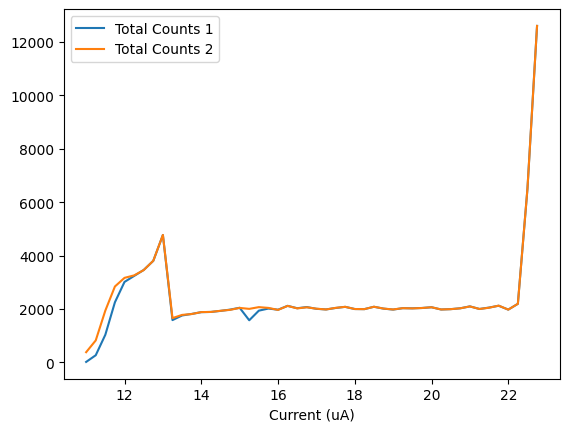

In [114]:
plt.plot(current*1e6, total_counts1)
plt.plot(current*1e6, total_counts2)
plt.xlabel('Current (uA)')
plt.legend(['Total Counts 1', 'Total Counts 2'])

Text(0.5, 1.0, 'Square Meander (RF Line 7)')

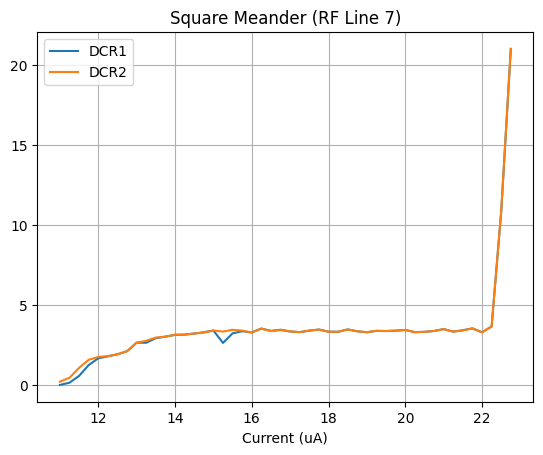

In [115]:
plt.plot(current*1e6, DCR1)
plt.plot(current*1e6, DCR2)
plt.xlabel('Current (uA)')
plt.legend(['DCR1', 'DCR2'])
plt.grid()
plt.title('Square Meander (RF Line 7)')

Text(0.5, 1.0, 'Square Meander (RF Line 7)')

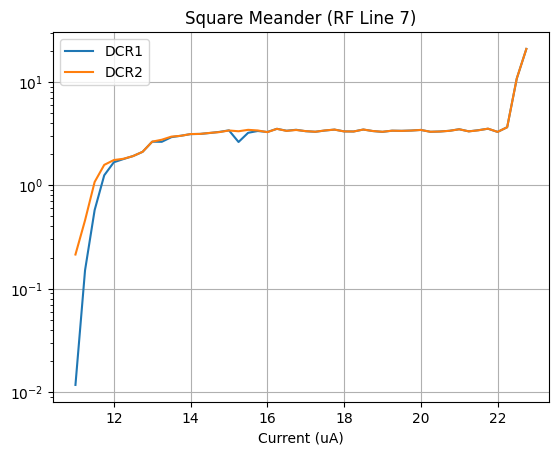

In [71]:
plt.semilogy(current*1e6, DCR1)
plt.semilogy(current*1e6, DCR2)
plt.xlabel('Current (uA)')
plt.legend(['DCR1', 'DCR2'])
plt.grid()
plt.title('Square Meander (RF Line 7)')

Text(0.5, 1.0, 'Square Meander (RF Line 7)')

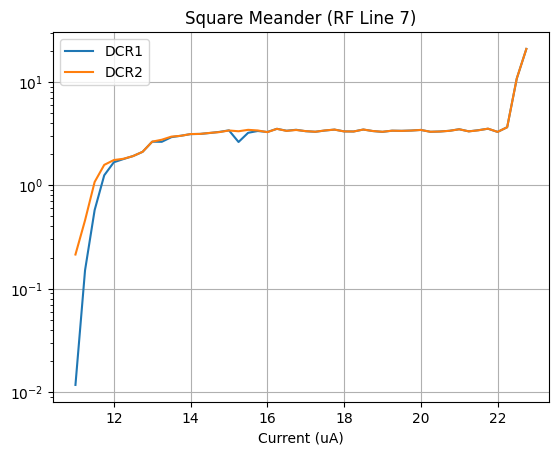

In [116]:
plt.semilogy(current*1e6, DCR1)
plt.semilogy(current*1e6, DCR2)
plt.xlabel('Current (uA)')
plt.legend(['DCR1', 'DCR2'])
plt.grid()
plt.title('Square Meander (RF Line 7)')

Came in and found it latched on current 22.75uA with no counts on scope. Why do the counts go up? 

In [60]:
current[-5:]*1e6

array([21.75, 22.  , 22.25, 22.5 , 22.75])

In [61]:
total_counts2[-5:]

array([ 2128.,  1979.,  2196.,  6512., 12599.])

In [64]:
idx = np.where(current == 22e-6)

In [65]:
print(total_counts1[idx], total_counts2[idx])

[1979.] [1979.]


In [66]:
print(DCR1[idx], DCR2[idx])

[3.29833333] [3.29833333]


In [74]:
counts1

array([0., 0., 0., ..., 0., 0., 0.], shape=(39458,))

Sanity check on DCR calculation. I don't think that acq_time in the code is right. 

In [90]:
acq_times

600

In [91]:
total_time

array([360., 360., 360., 360., 360., 360., 360., 360., 360., 120., 120.,
       120., 120., 120., 120., 120., 120., 120., 120., 120., 120., 120.,
       120., 120., 120., 120., 120., 120., 120., 120., 120., 120., 120.,
       120., 120., 120., 120., 120., 120., 120., 120., 120., 120., 120.,
       120., 120., 120., 120.])

In [92]:
bin_time

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [93]:
n_bins = total_time/bin_time # the code currently divides by the number of bins, not number of bins*trace time

In [101]:
n_bins

array([360., 360., 360., 360., 360., 360., 360., 360., 360., 120., 120.,
       120., 120., 120., 120., 120., 120., 120., 120., 120., 120., 120.,
       120., 120., 120., 120., 120., 120., 120., 120., 120., 120., 120.,
       120., 120., 120., 120., 120., 120., 120., 120., 120., 120., 120.,
       120., 120., 120., 120.])

In [94]:
trace_time[0]

np.float64(0.2)

In [95]:
meas_time = n_bins*trace_time[0]

In [96]:
meas_time

array([72., 72., 72., 72., 72., 72., 72., 72., 72., 24., 24., 24., 24.,
       24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
       24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
       24., 24., 24., 24., 24., 24., 24., 24., 24.])

In [97]:
DCR1_check = total_counts1/meas_time

In [117]:
total_time

array([1800., 1800., 1800., 1800., 1800., 1800., 1800., 1800., 1800.,
        600.,  600.,  600.,  600.,  600.,  600.,  600.,  600.,  600.,
        600.,  600.,  600.,  600.,  600.,  600.,  600.,  600.,  600.,
        600.,  600.,  600.,  600.,  600.,  600.,  600.,  600.,  600.,
        600.,  600.,  600.,  600.,  600.,  600.,  600.,  600.,  600.,
        600.,  600.,  600.])

total_time should have either been set to 1800 or 600 in the if statement block 

In [105]:
current

array([1.100e-05, 1.125e-05, 1.150e-05, 1.175e-05, 1.200e-05, 1.225e-05,
       1.250e-05, 1.275e-05, 1.300e-05, 1.325e-05, 1.350e-05, 1.375e-05,
       1.400e-05, 1.425e-05, 1.450e-05, 1.475e-05, 1.500e-05, 1.525e-05,
       1.550e-05, 1.575e-05, 1.600e-05, 1.625e-05, 1.650e-05, 1.675e-05,
       1.700e-05, 1.725e-05, 1.750e-05, 1.775e-05, 1.800e-05, 1.825e-05,
       1.850e-05, 1.875e-05, 1.900e-05, 1.925e-05, 1.950e-05, 1.975e-05,
       2.000e-05, 2.025e-05, 2.050e-05, 2.075e-05, 2.100e-05, 2.125e-05,
       2.150e-05, 2.175e-05, 2.200e-05, 2.225e-05, 2.250e-05, 2.275e-05])

In [104]:
threshold1

array([0.5  , 0.48 , 0.48 , 0.48 , 0.48 , 0.48 , 0.48 , 0.48 , 0.48 ,
       0.75 , 0.75 , 0.75 , 0.75 , 0.75 , 0.75 , 0.75 , 0.75 , 1.23 ,
       1.23 , 1.23 , 1.23 , 1.23 , 1.23 , 1.23 , 1.23 , 1.41 , 1.41 ,
       1.41 , 1.41 , 1.41 , 1.41 , 1.41 , 1.41 , 1.8  , 1.8  , 1.8  ,
       1.8  , 1.8  , 1.8  , 1.8  , 1.8  , 2.025, 2.025, 2.025, 2.025,
       2.025, 2.025, 2.025])

In [118]:
trace_time[0]

array([0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
       0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
       0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
       0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2])

In [122]:
n_captures = total_time
meas_time = trace_time[0]*n_captures
DCR1_corrected = total_counts1/meas_time

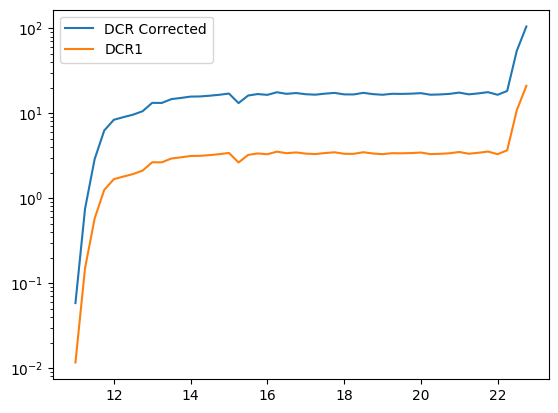

In [123]:
plt.semilogy(current*1e6, DCR1_corrected)
plt.semilogy(current*1e6, DCR1)
plt.legend(['DCR Corrected', 'DCR1'])
plt.xlabel('Current (uA)')

In [124]:
n_captures = total_time
meas_time = trace_time[0]*n_captures
DCR2_corrected = total_counts2/meas_time

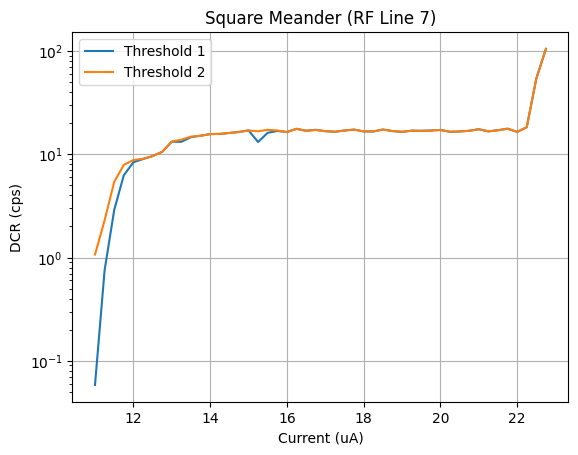

In [158]:
plt.semilogy(current*1e6, DCR1_corrected)
plt.semilogy(current*1e6, DCR2_corrected)
plt.xlabel('Current (uA)')
plt.ylabel('DCR (cps)')
plt.legend(['Threshold 1', 'Threshold 2'])
plt.title('Square Meander (RF Line 7)')
plt.grid()

plt.savefig('DCR_ID11_RF7.jpg') 

DCR calculation is fixed. 
Did the arrays of counts save? 

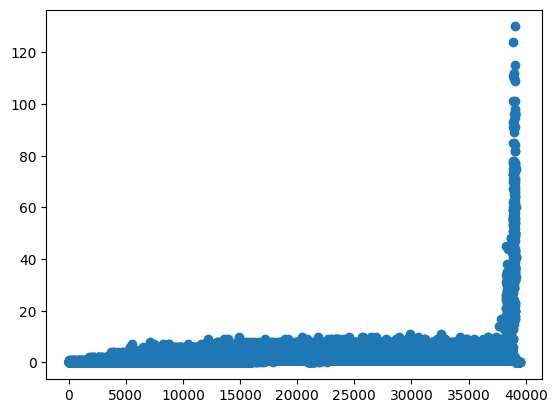

In [135]:
plt.plot(counts1, 'o')

In [133]:
len(counts1)

39458

In [134]:
len(currents)

48

In [141]:
sum(total_time)

np.float64(39600.0)

In [136]:
counts1

array([0., 0., 0., ..., 0., 0., 0.], shape=(39458,))

In [142]:
counts2

array([0., 1., 1., ..., 0., 0., 0.], shape=(39458,))

In [143]:
sum(total_time)-len(counts1)

np.float64(142.0)

In [146]:
total_counts1

array([   21.,   271.,  1038.,  2255.,  3016.,  3239.,  3463.,  3805.,
        4772.,  1587.,  1760.,  1817.,  1884.,  1892.,  1931.,  1979.,
        2048.,  1580.,  1940.,  2019.,  1975.,  2120.,  2031.,  2075.,
        2009.,  1985.,  2040.,  2083.,  2001.,  1997.,  2086.,  2016.,
        1980.,  2033.,  2027.,  2040.,  2068.,  1983.,  1997.,  2029.,
        2100.,  2003.,  2056.,  2124.,  1979.,  2196.,  6503., 12599.])

In [147]:
sum(counts1)

np.float64(114452.0)

In [148]:
sum(total_counts1)

np.float64(114452.0)

In [150]:
total_time

array([1800., 1800., 1800., 1800., 1800., 1800., 1800., 1800., 1800.,
        600.,  600.,  600.,  600.,  600.,  600.,  600.,  600.,  600.,
        600.,  600.,  600.,  600.,  600.,  600.,  600.,  600.,  600.,
        600.,  600.,  600.,  600.,  600.,  600.,  600.,  600.,  600.,
        600.,  600.,  600.,  600.,  600.,  600.,  600.,  600.,  600.,
        600.,  600.,  600.])

In [149]:
sum(counts1[:1800])

np.float64(23.0)

In [151]:
142/48 #~ 3 points missing on each? 

2.9583333333333335

In [152]:
# Look at last 600 to see if we can see latch
counts1[-600:]

array([ 16.,  18.,  33.,  39.,  39.,  70., 111.,  17.,   9.,   9.,  57.,
         1.,  39.,  71.,  22.,  22.,  32.,  73.,  53.,  49.,  49.,  67.,
        93.,  38.,  59.,  55.,  55.,  77.,  37.,  38., 124.,  59.,  59.,
        53.,  56.,  36.,  36.,  36.,  46.,   2.,  18.,  19.,  42.,  42.,
        22.,  73.,  75.,   2.,   2.,  62., 101.,  24.,  38.,  42.,  42.,
        60.,  54.,  28.,  51.,  51.,  73.,  21.,  85.,  41.,  56.,  56.,
        32.,   2.,  78.,  91.,  18.,  18.,  38.,  24.,  59.,  77.,  77.,
        56.,  18.,  34.,  15.,  75.,  75.,  71.,  78.,  43.,  59.,  56.,
        56.,  75.,  56.,  56.,  29.,  29.,  76.,  92.,  39.,  85.,  39.,
        39.,   1.,  21.,   2.,  38.,  38.,  20.,  56.,  40.,  19.,  19.,
        17.,  96.,  65.,  57.,  54.,  54.,  58.,  23.,  30.,  94.,  60.,
        60.,  58.,  39.,  52.,  60.,  60.,  67.,  39.,  63.,  55.,  36.,
        36.,  29., 112.,  72.,  33.,  33.,  18.,  63.,  91.,  68.,  54.,
        54.,  56.,  22.,  89., 110., 110.,  73.,  4

Rewriting function.

Now we specify how frequently we want to take captures (bin_length) and the number of captures we want to take (n_captures). 

In [ ]:
def count_rate_two(MS,bin_length, n_captures):
    # # Initialisation? 
    MS.write("SEARCH:SEARCH1:STATE 0")
    MS.write("SEARCH:SEARCH1:STATE 1")
    MS.write("SEARCH:SEARCH2:STATE 0")
    MS.write("SEARCH:SEARCH2:STATE 1")

    print(f'This acquisition will take {n_captures*bin_length}s')

    counts1= []
    counts2= []
    
    for i in range(n_captures):
        time.sleep(bin_length)

        # Extract counts 
        count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
        count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

        counts1.append(count1)
        counts2.append(count2)
        
    total_counts1 = sum(counts1)
    total_counts2 = sum(counts2)
        
    return counts1, total_counts1, counts2, total_counts2

In [154]:
current

array([1.100e-05, 1.125e-05, 1.150e-05, 1.175e-05, 1.200e-05, 1.225e-05,
       1.250e-05, 1.275e-05, 1.300e-05, 1.325e-05, 1.350e-05, 1.375e-05,
       1.400e-05, 1.425e-05, 1.450e-05, 1.475e-05, 1.500e-05, 1.525e-05,
       1.550e-05, 1.575e-05, 1.600e-05, 1.625e-05, 1.650e-05, 1.675e-05,
       1.700e-05, 1.725e-05, 1.750e-05, 1.775e-05, 1.800e-05, 1.825e-05,
       1.850e-05, 1.875e-05, 1.900e-05, 1.925e-05, 1.950e-05, 1.975e-05,
       2.000e-05, 2.025e-05, 2.050e-05, 2.075e-05, 2.100e-05, 2.125e-05,
       2.150e-05, 2.175e-05, 2.200e-05, 2.225e-05, 2.250e-05, 2.275e-05])

In [157]:
import pandas as pd

# Sample DataFrame
DCR_ID11 = {'DCR1': DCR1_corrected, 'DCR2': DCR2_corrected, 'current': current}
df = pd.DataFrame(DCR_ID11)

# Export to a CSV file named 'output_file.csv'
df.to_csv('DCR_ID11.csv')


ADjusting DCR sweep code for next run

In [171]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("DCR1", label="cps")
meas.register_custom_parameter("DCR2", label="cps")


trace_time = 200e-3
bin_length = 1 # s <-  
# currents = np.arange(11e-6, 23e-6, 0.25e-6)
n_captures = 10

currents = [11e-6, 15e-6, 20e-6]


with meas.run() as datasaver:
    print(datasaver.run_id)

    for current in currents: 
        # Set current 
        yoko.current(current)

        if current > 21e-6:
            threshold1 = 2.025 # in volts
            threshold2 = 0.5 # in volt
#             n_captures = 600  #<-

        elif current > 19e-6:
            threshold1 = 1.8 # in volts
            threshold2 = 0.5 # in volt
#             n_captures = 600 #<-

        elif current > 17e-6:
            threshold1 = 1.41 # in volts
            threshold2 = 0.5 # in volt
#             n_captures = 600 #<-

        elif current > 15e-6:
            threshold1 = 1.23 # in volts
            threshold2 = 0.5 # in volt
#             n_captures = 600 #<-

        elif current > 13e-6:
            threshold1 = 0.75 # in volts
            threshold2 = 0.5 # in volt
#             n_captures = 600 #<-

        elif current > 11e-6:
            threshold1 = 0.48 # in volts
            threshold2 = 0.425 # in volt
#             n_captures = 1800 #<-

        else:
            threshold1 = 0.5 # in volts
            threshold2 = 0.4 # in volt
#             n_captures = 1800 #<-


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        counts1, total_counts1, counts2, total_counts2 = count_rate_two(
        MS = MS, 
        bin_length = bin_length,
        n_captures = n_captures
        )
        
        print(current, counts1, total_counts1, counts2, total_counts2)
        meas_time = int(n_captures*trace_time)
        
        DCR1 = total_counts1/meas_time
        DCR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("DCR1", DCR1), 
                             ("DCR2", DCR2))
print('Finished!')

Starting experimental run with id: 16. 
16
This acquisition will take 10s
1.1e-05 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0] 0 [0, 2, 0, 0, 0, 0, 1, 0, 1, 0] 4
This acquisition will take 10s
1.5e-05 [3, 4, 1, 3, 3, 2, 2, 4, 2, 3] 27 [3, 4, 1, 3, 3, 2, 2, 4, 2, 3] 27
This acquisition will take 10s
2e-05 [4, 2, 4, 2, 3, 2, 4, 3, 4, 2] 30 [4, 2, 4, 2, 3, 2, 4, 3, 4, 2] 30
Finished!


In [177]:
data = load_by_id(16).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_time = data['bin_length']['bin_length']
DCR1 = data['DCR1']['DCR1']
DCR2 = data['DCR2']['DCR2']

In [178]:
counts1

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 3., 4., 1., 3., 3., 2., 2.,
       4., 2., 3., 4., 2., 4., 2., 3., 2., 4., 3., 4., 2.])

In [172]:
total_counts1

30

In [173]:
sum(counts1)

30

Trying to get the counts to save as embedded lists. I guess the others just concatenate on the values why would they save as lists? Ignoring that now and running something. 

In [194]:
n_captures = 2/200e-3

In [195]:
n_captures # 10 seconds give 2s measurement time 

10.0

In [197]:
len(np.arange(11e-6, 23e-6, 0.5e-6)) 

24

In [199]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("DCR1", label="cps")
meas.register_custom_parameter("DCR2", label="cps")
meas.register_custom_parameter("n_captures")


trace_time = 200e-3
bin_length = 1 # s <-  
currents = np.arange(11e-6, 23e-6, 0.25e-6)



with meas.run() as datasaver:
    print(datasaver.run_id)

    for current in currents: 
        # Set current 
        yoko.current(current)

        if current > 21e-6:
            threshold1 = 2.025 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 2  #<-

        elif current > 19e-6:
            threshold1 = 1.8 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 2 #<-

        elif current > 17e-6:
            threshold1 = 1.41 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 2 #<-

        elif current > 15e-6:
            threshold1 = 1.23 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 2 #<-

        elif current > 13e-6:
            threshold1 = 0.75 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 2 #<-

        elif current > 11e-6:
            threshold1 = 0.48 # in volts
            threshold2 = 0.425 # in volt
            n_captures = 6 #<-

        else:
            threshold1 = 0.5 # in volts
            threshold2 = 0.4 # in volt
            n_captures = 6 #<-


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        counts1, total_counts1, counts2, total_counts2 = count_rate_two(
        MS = MS, 
        bin_length = bin_length,
        n_captures = n_captures
        )
        
        print(current, counts1, total_counts1, counts2, total_counts2)
        meas_time = n_captures*trace_time
        
        DCR1 = total_counts1/meas_time
        DCR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("DCR1", DCR1), 
                             ("DCR2", DCR2))
        

print('Finished!')

Starting experimental run with id: 23. 
23
This acquisition will take 6s
1.1e-05 [0, 0, 0, 0, 0, 0] 0 [0, 0, 2, 0, 0, 0] 2
This acquisition will take 6s
1.1249999999999999e-05 [0, 0, 0, 1, 0, 0] 1 [0, 0, 0, 1, 0, 0] 1
This acquisition will take 6s
1.1499999999999998e-05 [1, 0, 0, 0, 0, 1] 2 [1, 0, 0, 0, 1, 1] 3
This acquisition will take 6s
1.1749999999999998e-05 [3, 1, 0, 1, 1, 0] 6 [4, 1, 0, 1, 1, 0] 7
This acquisition will take 6s
1.1999999999999997e-05 [4, 2, 1, 2, 2, 2] 13 [4, 2, 1, 2, 2, 2] 13
This acquisition will take 6s
1.2249999999999996e-05 [1, 2, 4, 2, 0, 4] 13 [1, 2, 4, 2, 0, 4] 13
This acquisition will take 6s
1.2499999999999996e-05 [4, 2, 0, 4, 3, 2] 15 [4, 2, 0, 5, 3, 2] 16
This acquisition will take 6s
1.2749999999999995e-05 [0, 2, 0, 4, 2, 3] 11 [0, 2, 0, 4, 2, 3] 11
This acquisition will take 6s
1.2999999999999994e-05 [2, 2, 4, 1, 1, 2] 12 [2, 2, 4, 1, 1, 2] 12
This acquisition will take 2s
1.3249999999999993e-05 [2, 2] 4 [2, 2] 4
This acquisition will take 2s
1.3499

In [207]:
data = load_by_id(23).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_time = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
DCR1 = data['DCR1']['DCR1']
DCR2 = data['DCR2']['DCR2']

[1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4]


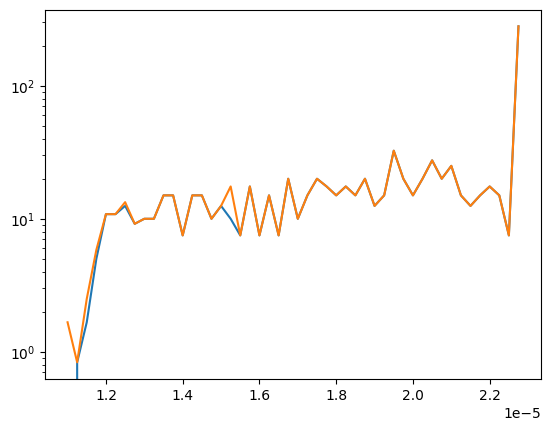

In [204]:
plt.semilogy(current, DCR1)
plt.semilogy(current, DCR2)

print(meas_time)

In [214]:
int(n_captures[-1])

2

In [215]:
counts1[-int(n_captures[-1]):]

array([79., 33.])

DDCR 13/2 (fiber port blanked) 

In [216]:
np.arange(11e-6, 23e-6, 0.25e-6)

array([1.100e-05, 1.125e-05, 1.150e-05, 1.175e-05, 1.200e-05, 1.225e-05,
       1.250e-05, 1.275e-05, 1.300e-05, 1.325e-05, 1.350e-05, 1.375e-05,
       1.400e-05, 1.425e-05, 1.450e-05, 1.475e-05, 1.500e-05, 1.525e-05,
       1.550e-05, 1.575e-05, 1.600e-05, 1.625e-05, 1.650e-05, 1.675e-05,
       1.700e-05, 1.725e-05, 1.750e-05, 1.775e-05, 1.800e-05, 1.825e-05,
       1.850e-05, 1.875e-05, 1.900e-05, 1.925e-05, 1.950e-05, 1.975e-05,
       2.000e-05, 2.025e-05, 2.050e-05, 2.075e-05, 2.100e-05, 2.125e-05,
       2.150e-05, 2.175e-05, 2.200e-05, 2.225e-05, 2.250e-05, 2.275e-05])

In [229]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("DCR1", label="cps")
meas.register_custom_parameter("DCR2", label="cps")
meas.register_custom_parameter("n_captures")


trace_time = 200e-3
bin_length = 1 # s <-  
currents = np.arange(11e-6, 23e-6, 0.25e-6)

with meas.run() as datasaver:
    print(datasaver.run_id)

    for current in currents: 
        # Set current 
        yoko.current(current)

        if current > 21e-6:
            threshold1 = 2.025 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 3600  #<-

        elif current > 19e-6:
            threshold1 = 1.8 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 3600 #<-

        elif current > 17e-6:
            threshold1 = 1.41 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 3600 #<-

        elif current > 15e-6:
            threshold1 = 1.23 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 3600 #<-

        elif current > 13e-6:
            threshold1 = 0.75 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 3600 #<-

        elif current > 11e-6:
            threshold1 = 0.48 # in volts
            threshold2 = 0.425 # in volt
            n_captures = 7200 #<-

        else:
            threshold1 = 0.5 # in volts
            threshold2 = 0.4 # in volt
            n_captures = 7200 #<-


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        counts1, total_counts1, counts2, total_counts2 = count_rate_two(
        MS = MS, 
        bin_length = bin_length,
        n_captures = n_captures
        )
        
        meas_time = n_captures*trace_time
        
        DCR1 = total_counts1/meas_time
        DCR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("DCR1", DCR1), 
                             ("DCR2", DCR2))
        

print('Finished!')

Starting experimental run with id: 24. 
24
This acquisition will take 7200s
14 59
Took: 624678.522038
This acquisition will take 7200s
17 0
Took: 631920.0809895
This acquisition will take 7200s
19 1
Took: 639160.9661604
This acquisition will take 7200s
21 1
Took: 646402.6459636
This acquisition will take 7200s
23 2
Took: 653644.1109656
This acquisition will take 7200s
1 3
Took: 660885.3741335
This acquisition will take 7200s
3 3
Took: 668127.0082391
This acquisition will take 7200s
5 4
Took: 675368.6813883
This acquisition will take 7200s
7 5
Took: 682610.4935459
This acquisition will take 3600s
9 5
Took: 686237.0753341
This acquisition will take 3600s
10 6
Took: 689857.2649094
This acquisition will take 3600s
11 6
Took: 693484.3123024
This acquisition will take 3600s
12 6
Took: 697105.1964234
This acquisition will take 3600s
13 7
Took: 700731.9514876
This acquisition will take 3600s
14 7
Took: 704352.6251395
This acquisition will take 3600s
15 8
Took: 707979.6467306
This acquisition w

In [230]:
data = load_by_id(24).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
DCR1 = data['DCR1']['DCR1']
DCR2 = data['DCR2']['DCR2']

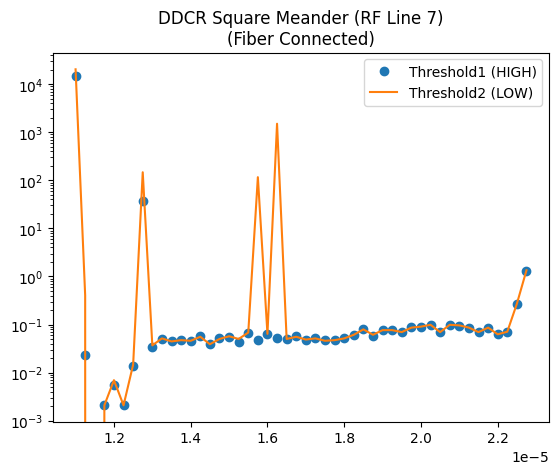

In [287]:
plt.title('DDCR Square Meander (RF Line 7)\n(Fiber Connected)')
plt.semilogy(current, DCR1, 'o')
plt.semilogy(current, DCR2)
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
# follows the trend of SDCR

Text(0.5, 1.0, 'Total Counts')

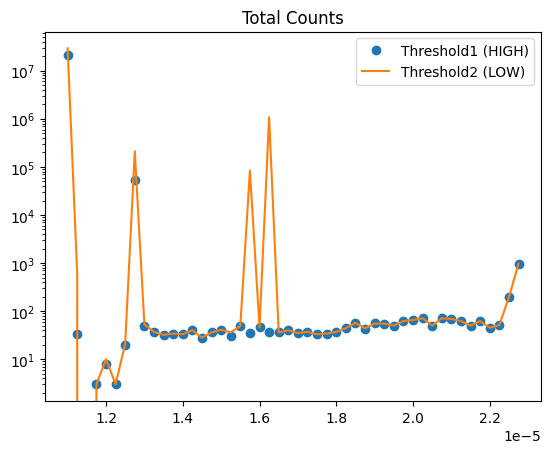

In [285]:
plt.semilogy(current, total_counts1, 'o')
plt.semilogy(current, total_counts2)
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.title('Total Counts')

In [249]:
idx = np.where(currents == 1.800e-05)

array([1.100e-05, 1.125e-05, 1.150e-05, 1.175e-05, 1.200e-05, 1.225e-05,
       1.250e-05, 1.275e-05, 1.300e-05, 1.325e-05, 1.350e-05, 1.375e-05,
       1.400e-05, 1.425e-05, 1.450e-05, 1.475e-05, 1.500e-05, 1.525e-05,
       1.550e-05, 1.575e-05, 1.600e-05, 1.625e-05, 1.650e-05, 1.675e-05,
       1.700e-05, 1.725e-05, 1.750e-05, 1.775e-05, 1.800e-05, 1.825e-05,
       1.850e-05, 1.875e-05, 1.900e-05, 1.925e-05, 1.950e-05, 1.975e-05,
       2.000e-05, 2.025e-05, 2.050e-05, 2.075e-05, 2.100e-05, 2.125e-05,
       2.150e-05, 2.175e-05, 2.200e-05, 2.225e-05, 2.250e-05, 2.275e-05])

In [239]:
n_captures

array([7200., 7200., 7200., 7200., 7200., 7200., 7200., 7200., 7200.,
       3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600.,
       3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600.,
       3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600.,
       3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600.,
       3600., 3600., 3600.])

(450.0, 550.0)

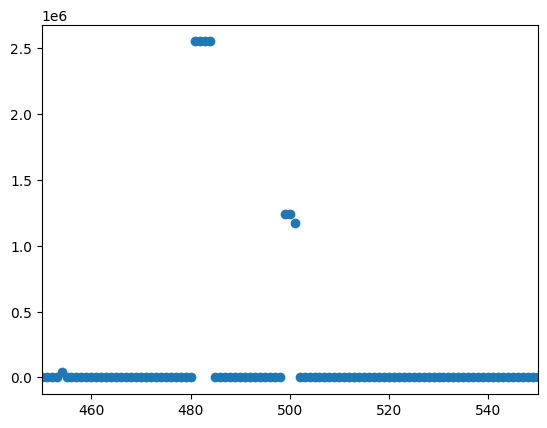

In [245]:
plt.plot(counts1[:int(n_captures[0])], 'o')
plt.xlim([450, 550])

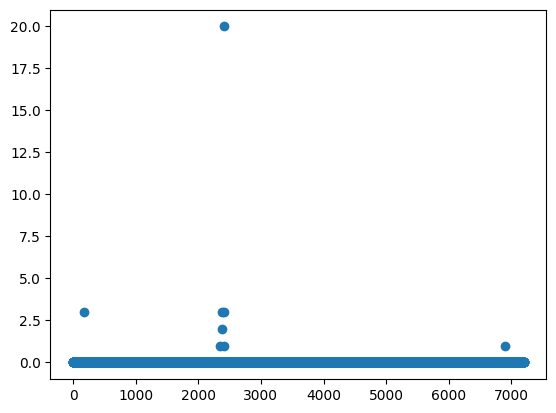

In [248]:
plt.plot(counts1[int(n_captures[0]):2*int(n_captures[1])], 'o')

In [281]:
sum(counts1[int(n_captures[0]):2*int(n_captures[1])])

np.float64(34.0)

In [255]:
currents

array([1.100e-05, 1.125e-05, 1.150e-05, 1.175e-05, 1.200e-05, 1.225e-05,
       1.250e-05, 1.275e-05, 1.300e-05, 1.325e-05, 1.350e-05, 1.375e-05,
       1.400e-05, 1.425e-05, 1.450e-05, 1.475e-05, 1.500e-05, 1.525e-05,
       1.550e-05, 1.575e-05, 1.600e-05, 1.625e-05, 1.650e-05, 1.675e-05,
       1.700e-05, 1.725e-05, 1.750e-05, 1.775e-05, 1.800e-05, 1.825e-05,
       1.850e-05, 1.875e-05, 1.900e-05, 1.925e-05, 1.950e-05, 1.975e-05,
       2.000e-05, 2.025e-05, 2.050e-05, 2.075e-05, 2.100e-05, 2.125e-05,
       2.150e-05, 2.175e-05, 2.200e-05, 2.225e-05, 2.250e-05, 2.275e-05])

In [267]:
n_captures

array([7200., 7200., 7200., 7200., 7200., 7200., 7200., 7200., 7200.,
       3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600.,
       3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600.,
       3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600.,
       3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600.,
       3600., 3600., 3600.])

In [264]:
currents[30]

np.float64(1.849999999999998e-05)

In [265]:
idx = 30

In [266]:
n_captures[idx]

np.float64(3600.0)

In [271]:
start = int(sum(n_captures[:idx])) # assuming this is 0 to 29 
stop = int(start + n_captures[idx])

Text(0.5, 1.0, 'Counts for current: 1.849999999999998e-05')

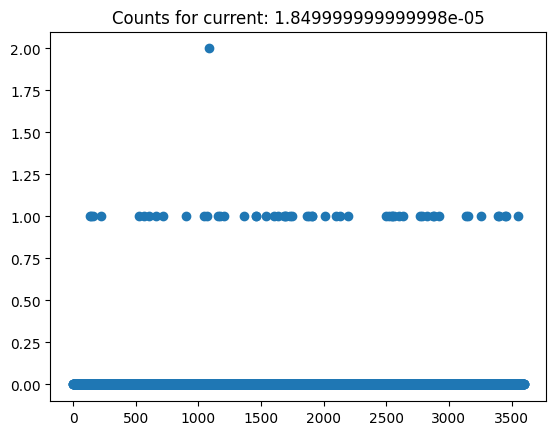

In [273]:
plt.plot(counts1[start:stop], 'o')
plt.title(f'Counts for current: {currents[idx]}')

In [274]:
meas_time[idx]

np.float64(720.0)

In [275]:
# DCR1 check 
DCR1_check = sum(counts1[start:stop])/meas_time[idx]
print(DCR1_check, DCR1[idx])

0.07916666666666666 0.0791666666666667


Setting up dark counts sweep for tuesday 

sum(n_captures)

In [289]:
24+8+10

42

In [293]:
57/2

28.5

In [291]:
sum(n_captures)/(3600) # last sweep took 57 hours 

np.float64(57.0)

In [294]:
currents

array([1.100e-05, 1.125e-05, 1.150e-05, 1.175e-05, 1.200e-05, 1.225e-05,
       1.250e-05, 1.275e-05, 1.300e-05, 1.325e-05, 1.350e-05, 1.375e-05,
       1.400e-05, 1.425e-05, 1.450e-05, 1.475e-05, 1.500e-05, 1.525e-05,
       1.550e-05, 1.575e-05, 1.600e-05, 1.625e-05, 1.650e-05, 1.675e-05,
       1.700e-05, 1.725e-05, 1.750e-05, 1.775e-05, 1.800e-05, 1.825e-05,
       1.850e-05, 1.875e-05, 1.900e-05, 1.925e-05, 1.950e-05, 1.975e-05,
       2.000e-05, 2.025e-05, 2.050e-05, 2.075e-05, 2.100e-05, 2.125e-05,
       2.150e-05, 2.175e-05, 2.200e-05, 2.225e-05, 2.250e-05, 2.275e-05])

In [300]:
np.arange(11e-6, 23.5e-6, 0.5e-6)

array([1.10e-05, 1.15e-05, 1.20e-05, 1.25e-05, 1.30e-05, 1.35e-05,
       1.40e-05, 1.45e-05, 1.50e-05, 1.55e-05, 1.60e-05, 1.65e-05,
       1.70e-05, 1.75e-05, 1.80e-05, 1.85e-05, 1.90e-05, 1.95e-05,
       2.00e-05, 2.05e-05, 2.10e-05, 2.15e-05, 2.20e-05, 2.25e-05,
       2.30e-05])

In [301]:
len(np.arange(11e-6, 23.5e-6, 0.5e-6))

25

In [302]:
(7200*4+3600*21)/3600

29.0

Run dark count sweep for square meander on, halving the number of current steps of time. Added another point to make sure we see the latch. 


RF Line 2 Square meander

In [303]:

meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("DCR1", label="cps")
meas.register_custom_parameter("DCR2", label="cps")
meas.register_custom_parameter("n_captures")


trace_time = 200e-3
bin_length = 1 # s <-  
currents = np.arange(11e-6, 23e-6, 0.5e-6) # <- halved number of current steps in the interest of time

currents = [22e-6]

with meas.run() as datasaver:
    print(datasaver.run_id)

    for current in currents: 
        # Set current 
        yoko.current(current)

        if current > 21e-6:
            threshold1 = 2.025 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 3600  #<-

        elif current > 19e-6:
            threshold1 = 1.8 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 3600 #<-

        elif current > 17e-6:
            threshold1 = 1.41 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 3600 #<-

        elif current > 15e-6:
            threshold1 = 1.23 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 3600 #<-

        elif current > 13e-6:
            threshold1 = 0.75 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 3600 #<-

        elif current > 11e-6:
            threshold1 = 0.48 # in volts
            threshold2 = 0.425 # in volt
            n_captures = 7200 #<-

        else:
            threshold1 = 0.5 # in volts
            threshold2 = 0.4 # in volt
            n_captures = 7200 #<-


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        counts1, total_counts1, counts2, total_counts2 = count_rate_two(
        MS = MS, 
        bin_length = bin_length,
        n_captures = n_captures
        )
        
        meas_time = n_captures*trace_time
        
        DCR1 = total_counts1/meas_time
        DCR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("DCR1", DCR1), 
                             ("DCR2", DCR2))
        

print('Finished!')

Starting experimental run with id: 25. 
25
This acquisition will take 3600s
15 2
Took: 880413.4854971
Finished!


In [304]:
data = load_by_id(25).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
DCR1 = data['DCR1']['DCR1']
DCR2 = data['DCR2']['DCR2']

In [308]:
sum(counts1)

np.float64(0.0)

In [305]:
total_counts1

array([0.])

In [306]:
DCR1

array([0.])

No dark counts seen. Try running for multiple sets of 1hr to get a ball park on how long we have to wait to see one at a high bias current. 

In [310]:
np.ones(16)*18.5e-6

array([1.85e-05, 1.85e-05, 1.85e-05, 1.85e-05, 1.85e-05, 1.85e-05,
       1.85e-05, 1.85e-05, 1.85e-05, 1.85e-05, 1.85e-05, 1.85e-05,
       1.85e-05, 1.85e-05, 1.85e-05, 1.85e-05])

In [311]:

meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("DCR1", label="cps")
meas.register_custom_parameter("DCR2", label="cps")
meas.register_custom_parameter("n_captures")


trace_time = 200e-3
bin_length = 1 # s <-  
currents = np.arange(11e-6, 23e-6, 0.5e-6) # <- halved number of current steps in the interest of time

# run for 16 hours
currents = np.ones(16)*18.5e-6

with meas.run() as datasaver:
    print(datasaver.run_id)

    for current in currents: 
        # Set current 
        yoko.current(current)

        if current > 21e-6:
            threshold1 = 2.025 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 3600  #<-

        elif current > 19e-6:
            threshold1 = 1.8 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 3600 #<-

        elif current > 17e-6:
            threshold1 = 1.41 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 3600 #<-

        elif current > 15e-6:
            threshold1 = 1.23 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 3600 #<-

        elif current > 13e-6:
            threshold1 = 0.75 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 3600 #<-

        elif current > 11e-6:
            threshold1 = 0.48 # in volts
            threshold2 = 0.425 # in volt
            n_captures = 7200 #<-

        else:
            threshold1 = 0.5 # in volts
            threshold2 = 0.4 # in volt
            n_captures = 7200 #<-


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        counts1, total_counts1, counts2, total_counts2 = count_rate_two(
        MS = MS, 
        bin_length = bin_length,
        n_captures = n_captures
        )
        
        meas_time = n_captures*trace_time
        
        DCR1 = total_counts1/meas_time
        DCR2 = total_counts2/meas_time
        
        print(f'Total counts threshold 1: {total_counts1}')
        print(f'Total counts threshold 2: {total_counts2}')
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("DCR1", DCR1), 
                             ("DCR2", DCR2))
        

print('Finished!')

Starting experimental run with id: 26. 
26
This acquisition will take 3600s
16 15
Took: 884781.4778207
Total counts threshold 1: 0
Total counts threshold 2: 0
This acquisition will take 3600s
17 15
Took: 888406.4099819
Total counts threshold 1: 0
Total counts threshold 2: 0
This acquisition will take 3600s
18 15
Took: 892024.9399372
Total counts threshold 1: 0
Total counts threshold 2: 0
This acquisition will take 3600s
19 16
Took: 895649.9100504
Total counts threshold 1: 0
Total counts threshold 2: 0
This acquisition will take 3600s
20 16
Took: 899268.6268125
Total counts threshold 1: 0
Total counts threshold 2: 0
This acquisition will take 3600s
21 16
Took: 902893.4058044
Total counts threshold 1: 1
Total counts threshold 2: 1
This acquisition will take 3600s
22 17
Took: 906512.0767485
Total counts threshold 1: 0
Total counts threshold 2: 1
This acquisition will take 3600s
23 17
Took: 910136.9009915
Total counts threshold 1: 0
Total counts threshold 2: 0
This acquisition will take 36

In [312]:
data = load_by_id(26).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
DCR1 = data['DCR1']['DCR1']
DCR2 = data['DCR2']['DCR2']

In [313]:
total_counts1

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [314]:
counts1

array([0., 0., 0., ..., 0., 0., 0.], shape=(57600,))

18/2/26
RF line 2, checking other currents to see how long it takes to see counts/get statistics 

In [328]:
currents = np.concatenate((np.ones(10)*15e-6, np.ones(8)*22e-6))

In [329]:
currents

array([1.5e-05, 1.5e-05, 1.5e-05, 1.5e-05, 1.5e-05, 1.5e-05, 1.5e-05,
       1.5e-05, 1.5e-05, 1.5e-05, 2.2e-05, 2.2e-05, 2.2e-05, 2.2e-05,
       2.2e-05, 2.2e-05, 2.2e-05, 2.2e-05])

In [331]:

meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("DCR1", label="cps")
meas.register_custom_parameter("DCR2", label="cps")
meas.register_custom_parameter("n_captures")


trace_time = 200e-3
bin_length = 1 # s <-  
currents = np.arange(11e-6, 23e-6, 0.5e-6) # <- halved number of current steps in the interest of time

# run for 16 hours
currents = np.concatenate((np.ones(10)*15e-6, np.ones(8)*22e-6))

with meas.run() as datasaver:
    print(datasaver.run_id)

    for current in currents: 
        # Set current 
        yoko.current(current)

        if current > 21e-6:
            threshold1 = 2.025 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 3600  #<-

        elif current > 19e-6:
            threshold1 = 1.8 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 3600 #<-

        elif current > 17e-6:
            threshold1 = 1.41 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 3600 #<-

        elif current > 15e-6:
            threshold1 = 1.23 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 3600 #<-

        elif current > 13e-6:
            threshold1 = 0.75 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 3600 #<-

        elif current > 11e-6:
            threshold1 = 0.48 # in volts
            threshold2 = 0.425 # in volt
            n_captures = 7200 #<-

        else:
            threshold1 = 0.5 # in volts
            threshold2 = 0.4 # in volt
            n_captures = 7200 #<-


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        counts1, total_counts1, counts2, total_counts2 = count_rate_two(
        MS = MS, 
        bin_length = bin_length,
        n_captures = n_captures
        )
        
        meas_time = n_captures*trace_time
        
        DCR1 = total_counts1/meas_time
        DCR2 = total_counts2/meas_time
        
        print(f'Total counts threshold 1: {total_counts1}')
        print(f'Total counts threshold 2: {total_counts2}')
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("DCR1", DCR1), 
                             ("DCR2", DCR2))
        

yoko.current(0)

print('Finished!')
print(f'Current: {yoko.current()}')

Starting experimental run with id: 27. 
27
This acquisition will take 3600s
15 34
Took: 1055120.8445977
Total counts threshold 1: 0
Total counts threshold 2: 0
This acquisition will take 3600s
16 34
Took: 1058745.7726766
Total counts threshold 1: 0
Total counts threshold 2: 0
This acquisition will take 3600s
17 34
Took: 1062370.8040507
Total counts threshold 1: 0
Total counts threshold 2: 0
This acquisition will take 3600s
18 35
Took: 1065995.7878337
Total counts threshold 1: 0
Total counts threshold 2: 0
This acquisition will take 3600s
19 35
Took: 1069620.6862113
Total counts threshold 1: 0
Total counts threshold 2: 0
This acquisition will take 3600s
20 36
Took: 1073245.3834632
Total counts threshold 1: 0
Total counts threshold 2: 0
This acquisition will take 3600s
21 36
Took: 1076870.2146738
Total counts threshold 1: 0
Total counts threshold 2: 0
This acquisition will take 3600s
22 36
Took: 1080495.1119372
Total counts threshold 1: 0
Total counts threshold 2: 0
This acquisition will

In [334]:

meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("DCR1", label="cps")
meas.register_custom_parameter("DCR2", label="cps")
meas.register_custom_parameter("n_captures")


trace_time = 200e-3
bin_length = 1 # s <-  
currents = np.arange(12e-6, 22e-6, 2e-6) # 

# run for ? hours
currents = [12e-6, 14e-6, 16e-6, 18e-6, 19e-6, 20e-6, 21e-6, 22e-6]

with meas.run() as datasaver:
    print(datasaver.run_id)

    for current in currents: 
        # Set current 
        yoko.current(current)

        if current > 21e-6:
            threshold1 = 2.025 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 18000  #<-

        elif current > 18e-6:
            threshold1 = 1.8 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 36000 #<-

        elif current > 17e-6:
            threshold1 = 1.41 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 54000 #<-

        elif current > 15e-6:
            threshold1 = 1.23 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 54000 #<-

        elif current > 13e-6:
            threshold1 = 0.75 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 54000 #<-

        elif current > 11e-6:
            threshold1 = 0.48 # in volts
            threshold2 = 0.425 # in volt
            n_captures = 54000 #<-

        else:
            threshold1 = 0.5 # in volts
            threshold2 = 0.4 # in volt
            n_captures = 54000 #<-


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        counts1, total_counts1, counts2, total_counts2 = count_rate_two(
        MS = MS, 
        bin_length = bin_length,
        n_captures = n_captures
        )
        
        meas_time = n_captures*trace_time
        
        DCR1 = total_counts1/meas_time
        DCR2 = total_counts2/meas_time
        
        print(f'Total counts threshold 1: {total_counts1}')
        print(f'Total counts threshold 2: {total_counts2}')
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("DCR1", DCR1), 
                             ("DCR2", DCR2))
        

yoko.current(0)

print('Finished!')
print(f'Current: {yoko.current()}')

Starting experimental run with id: 28. 
28
This acquisition will take 54000s
16 14
Took: 1194504.9418936
Total counts threshold 1: 0
Total counts threshold 2: 0
This acquisition will take 54000s
7 17
Took: 1248706.2552997
Total counts threshold 1: 0
Total counts threshold 2: 0
This acquisition will take 54000s
22 20


An exception occurred in measurement with guid: 276fda21-0000-0000-0000-019c7451c566;
Traceback:
Traceback (most recent call last):
  File "C:\Users\QNL\AppData\Local\Temp\ipykernel_28028\1409360638.py", line 74, in <module>
    counts1, total_counts1, counts2, total_counts2 = count_rate_two(
                                                     ^^^^^^^^^^^^^^^
  File "C:\Users\QNL\AppData\Local\Temp\ipykernel_28028\1621932665.py", line 19, in count_rate_two
    time.sleep(bin_length)
KeyboardInterrupt



KeyboardInterrupt: 

Stopped after 14uA

In [333]:
currents = [12e-6, 14e-6, 16e-6, 18e-6, 19e-6, 20e-6, 21e-6, 22e-6]
currents

[1.2e-05, 1.4e-05, 1.6e-05, 1.8e-05, 1.9e-05, 2e-05, 2.1e-05, 2.2e-05]

In [335]:
data = load_by_id(28).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
DCR1 = data['DCR1']['DCR1']
DCR2 = data['DCR2']['DCR2']

In [337]:
total_counts1

array([0., 0.])

In [338]:
total_counts1

array([0., 0.])

Connected to RF line 12 old device 

In [343]:
54000 + 36000 + 36000 + 36000 + 36000 # seconds

198000

In [344]:
198000/3600 # hours in sweep 

55.0

In [342]:
#hours 

24 + 24 + 10 # midnight on monday to 10am

58

In [345]:

meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("DCR1", label="cps")
meas.register_custom_parameter("DCR2", label="cps")
meas.register_custom_parameter("n_captures")


trace_time = 200e-3
bin_length = 1 # s <-  
# run for ? hours
currents = [18e-6, 19e-6, 20e-6, 21e-6, 22e-6]

with meas.run() as datasaver:
    print(datasaver.run_id)

    for current in currents: 
        # Set current 
        yoko.current(current)

        if current > 21e-6:
            threshold1 = 2.025 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 36000  #<-

        elif current > 18e-6:
            threshold1 = 1.8 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 36000 #<-

        elif current > 17e-6:
            threshold1 = 1.41 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 54000 #<-

        elif current > 15e-6:
            threshold1 = 1.23 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 54000 #<-

        elif current > 13e-6:
            threshold1 = 0.75 # in volts
            threshold2 = 0.5 # in volt
            n_captures = 54000 #<-

        elif current > 11e-6:
            threshold1 = 0.48 # in volts
            threshold2 = 0.425 # in volt
            n_captures = 54000 #<-

        else:
            threshold1 = 0.5 # in volts
            threshold2 = 0.4 # in volt
            n_captures = 54000 #<-


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        counts1, total_counts1, counts2, total_counts2 = count_rate_two(
        MS = MS, 
        bin_length = bin_length,
        n_captures = n_captures
        )
        
        meas_time = n_captures*trace_time
        
        DCR1 = total_counts1/meas_time
        DCR2 = total_counts2/meas_time
        
        print(f'Total counts threshold 1: {total_counts1}')
        print(f'Total counts threshold 2: {total_counts2}')
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("DCR1", DCR1), 
                             ("DCR2", DCR2))
        

yoko.current(0)

print('Finished!')
print(f'Current: {yoko.current()}')

Starting experimental run with id: 29. 
29
This acquisition will take 54000s
23 27


An exception occurred in measurement with guid: 0a4ed4e7-0000-0000-0000-019c7b04fe02;
Traceback:
Traceback (most recent call last):
  File "C:\Users\QNL\AppData\Local\Temp\ipykernel_28028\55418761.py", line 72, in <module>
    counts1, total_counts1, counts2, total_counts2 = count_rate_two(
                                                     ^^^^^^^^^^^^^^^
  File "C:\Users\QNL\AppData\Local\Temp\ipykernel_28028\1621932665.py", line 19, in count_rate_two
    time.sleep(bin_length)
KeyboardInterrupt



KeyboardInterrupt: 

Device latched straight away!!! 

Footage taken. Transition at about 10.9uA. Aligns with earlier result that this device latches much lower. 

In [346]:

meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("DCR1", label="cps")
meas.register_custom_parameter("DCR2", label="cps")
meas.register_custom_parameter("n_captures")


trace_time = 200e-3
bin_length = 1 # s <-  
# run for ? hours
# the thresholds for this device will be completely different and hard to find. Just try 500mV and 1V to get an indication of what
# the counts are like
# Noise floor on scope is at about 400mV 
currents = [8.5e-6, 9e-6, 9.5e-6, 10e-6, 10.5e-6]
n_captures = 36000 # 10 hours for each current 
threshold1 = 1 # in volts
threshold2 = 0.5 # in volt

with meas.run() as datasaver:
    print(datasaver.run_id)

    for current in currents: 
        # Set current 
        yoko.current(current)


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        counts1, total_counts1, counts2, total_counts2 = count_rate_two(
        MS = MS, 
        bin_length = bin_length,
        n_captures = n_captures
        )
        
        meas_time = n_captures*trace_time
        
        DCR1 = total_counts1/meas_time
        DCR2 = total_counts2/meas_time
        
        print(f'Total counts threshold 1: {total_counts1}')
        print(f'Total counts threshold 2: {total_counts2}')
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("DCR1", DCR1), 
                             ("DCR2", DCR2))
        

yoko.current(0)

print('Finished!')
print(f'Current: {yoko.current()}')

Starting experimental run with id: 30. 
30
This acquisition will take 36000s
23 42
Took: 1289769.9948317
Total counts threshold 1: 0
Total counts threshold 2: 0
This acquisition will take 36000s
9 45
Took: 1325912.9568261
Total counts threshold 1: 0
Total counts threshold 2: 0
This acquisition will take 36000s
19 47
Took: 1362049.1827272
Total counts threshold 1: 185814
Total counts threshold 2: 1462086
This acquisition will take 36000s
5 49
Took: 1398183.9027063
Total counts threshold 1: 0
Total counts threshold 2: 0
This acquisition will take 36000s
15 52
Took: 1434317.7883353
Total counts threshold 1: 0
Total counts threshold 2: 0
Finished!
Current: 0.0


23/2

DMM connected in 4-wire. Sweep RF Line 12 to check critical current. 

In [348]:
print(f'Current: {yoko.current()}')

Current: 0.0


In [349]:
dmm.volt()

7.65017119e-05

In [358]:
currents = np.linspace(5e-6, 15e-6, 21)
voltages = []
ratios = []


for curr in currents: 
    yoko.current(curr)
    time.sleep(1)
    voltage = dmm.volt()
    ratio = voltage/curr 
    ratios.append(ratio)
    voltages.append(voltage)

Text(0, 0.5, 'voltage')

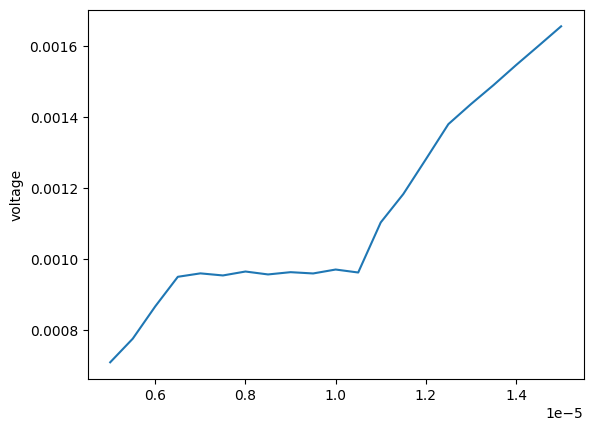

In [362]:
plt.plot(currents, voltages)
plt.ylabel('voltage')

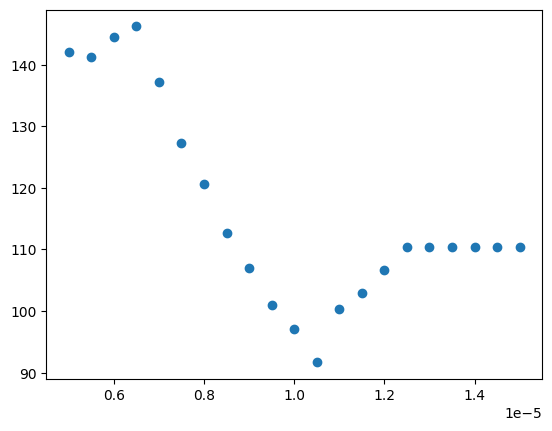

In [363]:
plt.plot(currents, ratios, 'o')

with meas.run() as datasaver:
    print(datasaver.run_id)
    # run in reverse 
    for i in currents[::-1]:
        yoko.current(i)
        time.sleep(2)
        datasaver.add_result(("n", n()),
                            (dmm.volt, dmm.volt()/yoko.current()),
                            (yoko.current, yoko.current()))
        time.sleep(0.1)

In [366]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)


currents = np.linspace(0, 20e-6, 51)

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

Starting experimental run with id: 32. 
32
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Ramping down
Current is 0.0


In [368]:
data = load_by_id(32).get_parameter_data()

In [372]:
voltage

array([7.71741494e-05, 1.20774188e-04, 1.64836797e-04, 2.08955944e-04,
       2.52683772e-04, 2.96399677e-04, 3.39842015e-04, 3.84484945e-04,
       4.28108831e-04, 4.72267031e-04, 5.16548450e-04, 5.60925069e-04,
       6.76246994e-04, 7.36188551e-04, 7.93671492e-04, 8.67417451e-04,
       9.57959146e-04, 9.61103218e-04, 9.61244025e-04, 9.55005467e-04,
       9.55489797e-04, 9.57355274e-04, 9.58208268e-04, 9.58527145e-04,
       9.59609585e-04, 9.67357176e-04, 9.71022442e-04, 1.06667813e-03,
       1.14047079e-03, 1.19676536e-03, 1.31480059e-03, 1.36963054e-03,
       1.41403966e-03, 1.45762280e-03, 1.50247997e-03, 1.54592390e-03,
       1.58908353e-03, 1.63317654e-03, 1.67710440e-03, 1.72040017e-03,
       1.76475314e-03, 1.80863609e-03, 1.85246289e-03, 1.89634911e-03,
       1.94004286e-03, 1.98352981e-03, 2.02757761e-03, 2.07178808e-03,
       2.11648775e-03, 2.15961290e-03, 2.20395871e-03])

Text(0.5, 1.0, 'RF Line 12')

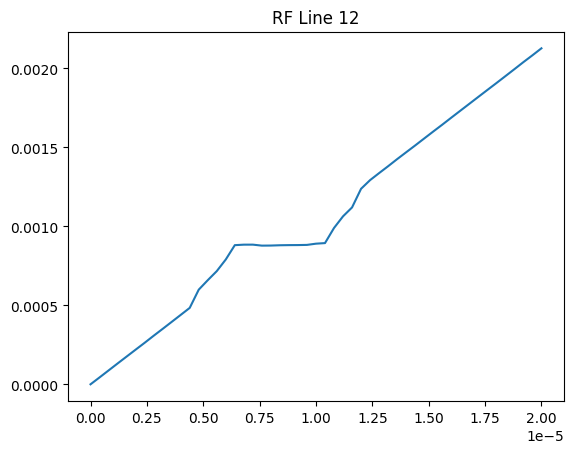

In [382]:
data = load_by_id(32).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']

plt.plot(current, voltage-voltage[0])
plt.title('RF Line 12')

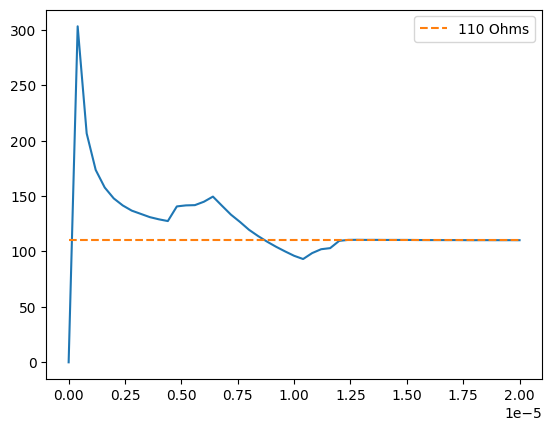

In [380]:
plt.plot(current, ratio)
plt.plot(current, np.ones_like(current)*110, '--', label='110 Ohms')
plt.legend()

In [391]:
MS.trigger_mode()

'NORMAL'

In [388]:
wav=MS.waveform_data()

In [390]:
len(wav)

1250

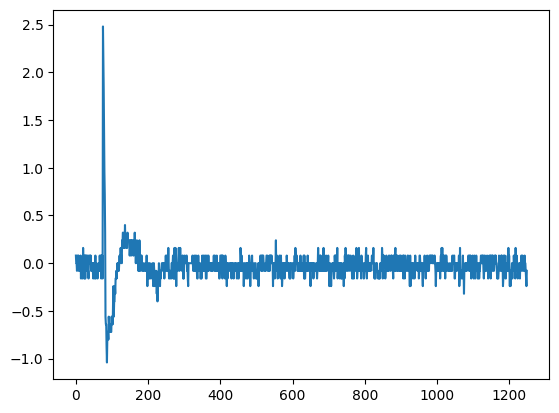

In [389]:
plt.plot(wav)

In [392]:
MS.horizontal_mode_record_length()

'1250'

In [393]:
MS.horizontal_mode_sample_rate()

312500000.0

In [394]:
MS.waveform_points()

1250

In [395]:
MS.timebase()

4e-07

In [396]:
MS.horizontal_delay()

0.0

In [397]:
MS.horizontal_mode()

'MANUAL'

In [410]:
MS.ask('DATa:SOUrce?')

'CH1'

In [402]:
MS.data_source()

'CH1'

In [409]:
MS.ask('WFMOutpre?')

'1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 512V/div, 400ns/div, 1250 points, Sample mode";1250;Y;LINEAR;"s";3.20E-9;1.550E-9;75;"V";80.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1'

In [412]:
MS.trigger_mode('NORM')

In [413]:
MS.trigger_mode('AUTO')

In [414]:
preamble = MS.ask('WFMOutpre?')

In [417]:
wav2=MS.waveform_data()

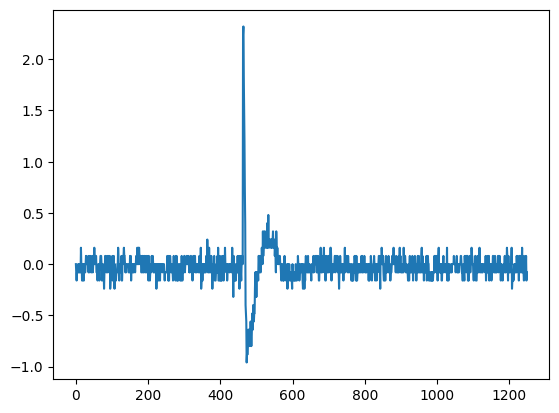

In [418]:
plt.plot(wav2)

In [415]:
MS.ask('WFMOutpre?')

'1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 512V/div, 400ns/div, 1250 points, Sample mode";1250;Y;LINEAR;"s";3.20E-9;479.9999999999272E-12;463;"V";80.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1'

In [420]:
MS.ask('WFMOutpre?')

'1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 512V/div, 400ns/div, 1250 points, Sample mode";1250;Y;LINEAR;"s";3.20E-9;479.9999999999272E-12;463;"V";80.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1'

In [421]:
MS.ask('HORIZONTAL?')

'0;0;1;0;2;OFF;1;10;S;0.0E+0;0;312.5000E+6;1;3.1250E+9;MANUAL;1;1250;HORIZONTALSCALE;10.0000;4.0000E-6;400.0000E-9;1250'

In [422]:
MS.ask('HORizontal:POSition?')

'10.0000'

In [423]:
MS.ask('WFMOutpre?')

'1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 512V/div, 400ns/div, 1250 points, Sample mode";1250;Y;LINEAR;"s";3.20E-9;479.9999999999272E-12;463;"V";80.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1'

In [458]:
wav3=MS.waveform_data()

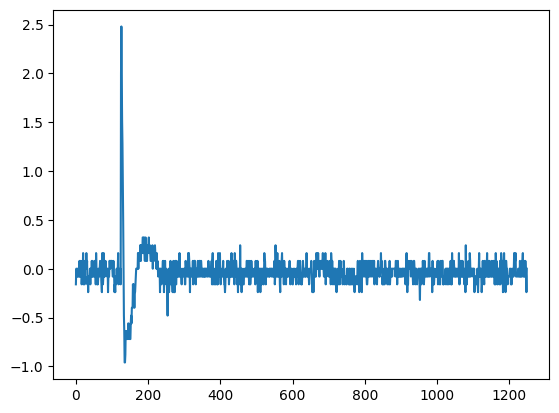

In [459]:
plt.plot(wav3)

In [426]:
h_scale = MS.ask('HORizontal:scale?')

'400.0000E-9'

In [437]:
MS.ask('HORizontal:MODe:RECOrdlength?')

'1250'

In [438]:
h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))

In [429]:
MS.ask('HORizontal:MODe:SAMPLERate?')

'312.5000E+6'

In [446]:
MS.ask('HORizontal:MODe:SAMPLERate?')

'312.5000E+6'

In [447]:
h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))

In [441]:
h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 

In [442]:
h_centre = h_samples*h_position_perc/100

In [443]:
h_centre

125.0

In [449]:
# samples to voltage divide by sample rate 
h_centre_t = h_centre/h_samplerate


In [455]:
h_t = np.arange(0, h_samples, 1)/h_samplerate - h_centre_t

In [456]:
h_t

array([-4.0000e-07, -3.9680e-07, -3.9360e-07, ...,  3.5904e-06,
        3.5936e-06,  3.5968e-06], shape=(1250,))

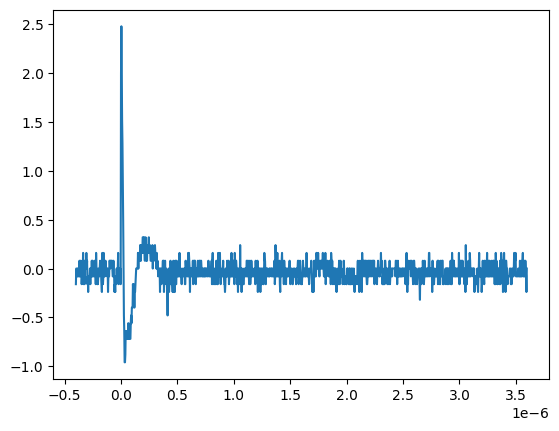

In [462]:
plt.plot(h_t, wav3)

In [465]:
MS.ask('TRIGger:A:LEVel:CH1?')

'1.4400'

In [ ]:
wav4=MS.waveform_data()
preamble = MS.ask('WFMOutpre?')

In [478]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')

Starting experimental run with id: 36. 
36
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 160ns/div, 1000 points, Sample mode";1000;Y;LINEAR;"s";1.60E-9;250.00E-12;100;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

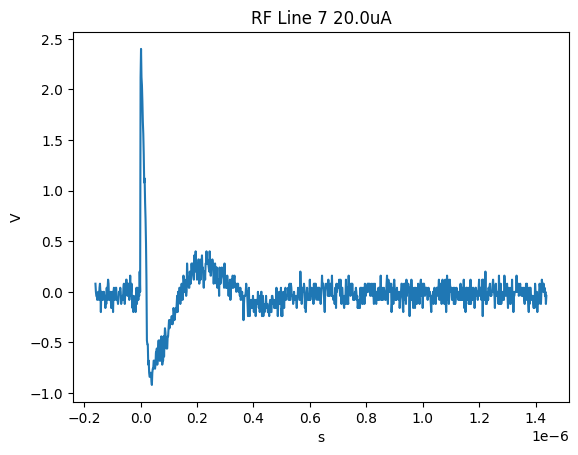

In [483]:
data = load_by_id(36).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'RF Line 7 {current*1e6}uA')
plt.xlabel('s')
plt.ylabel('V')

In [484]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')

Starting experimental run with id: 37. 
37
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 160ns/div, 1000 points, Sample mode";1000;Y;LINEAR;"s";1.60E-9;930.00E-12;100;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

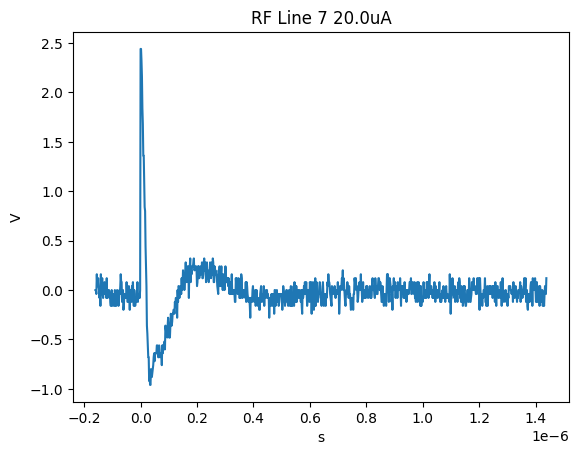

In [485]:
data = load_by_id(37).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'RF Line 7 {current*1e6}uA')
plt.xlabel('s')
plt.ylabel('V')

Starting experimental run with id: 38. 
38
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 160ns/div, 1000 points, Sample mode";1000;Y;LINEAR;"s";1.60E-9;930.00E-12;100;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

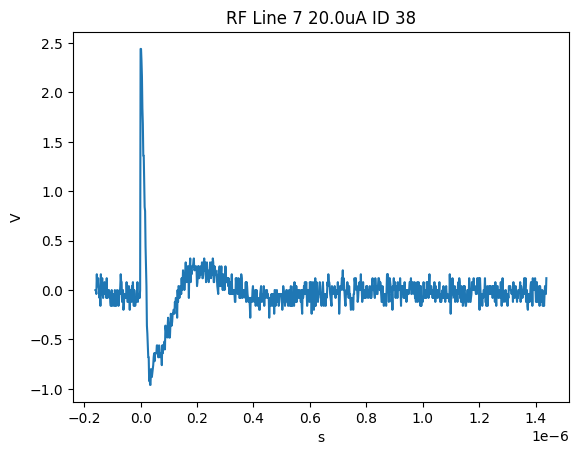

In [487]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'RF Line 7 {current*1e6}uA ID {datasaver.run_id}')
plt.xlabel('s')
plt.ylabel('V')

Starting experimental run with id: 39. 
39
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 160ns/div, 1000 points, Sample mode";1000;Y;LINEAR;"s";1.60E-9;985.000E-12;100;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

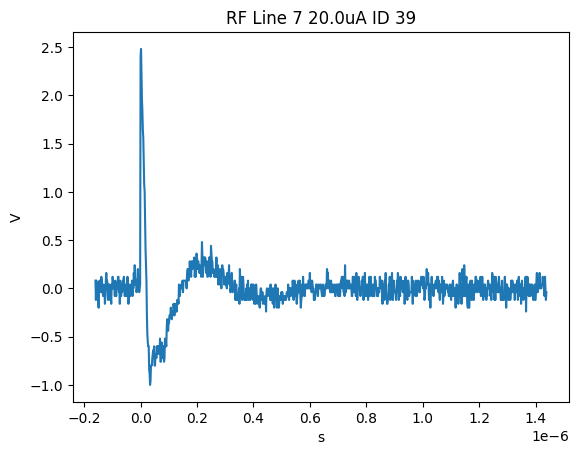

In [488]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'RF Line 7 {current*1e6}uA ID {datasaver.run_id}')
plt.xlabel('s')
plt.ylabel('V')

Starting experimental run with id: 40. 
40
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 160ns/div, 1000 points, Sample mode";1000;Y;LINEAR;"s";1.60E-9;1.260E-9;100;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

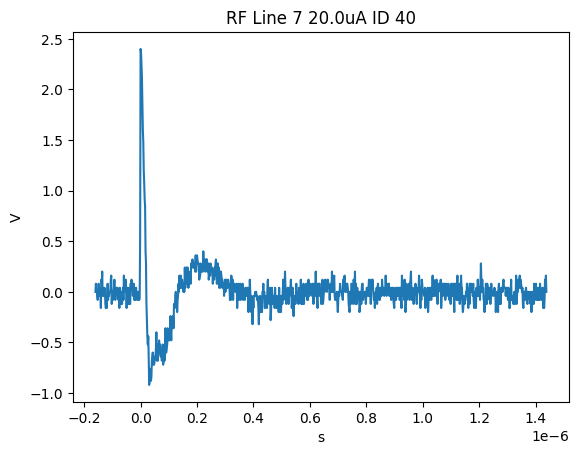

In [489]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'RF Line 7 {current*1e6}uA ID {datasaver.run_id}')
plt.xlabel('s')
plt.ylabel('V')

Starting experimental run with id: 41. 
41
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 160ns/div, 1000 points, Sample mode";1000;Y;LINEAR;"s";1.60E-9;1.5350E-9;100;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

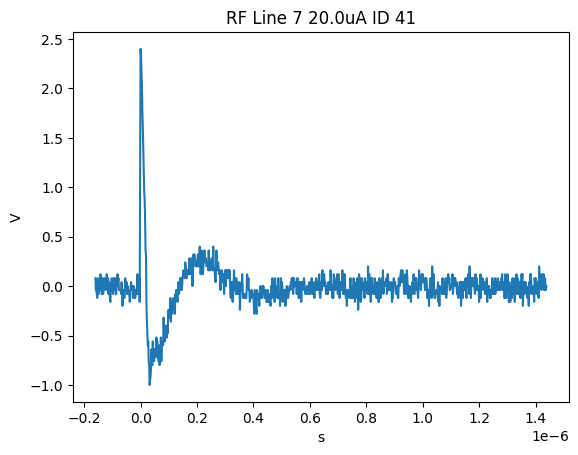

In [490]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'RF Line 7 {current*1e6}uA ID {datasaver.run_id}')
plt.xlabel('s')
plt.ylabel('V')

Starting experimental run with id: 42. 
42
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 160ns/div, 1000 points, Sample mode";1000;Y;LINEAR;"s";1.60E-9;1.1650E-9;100;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

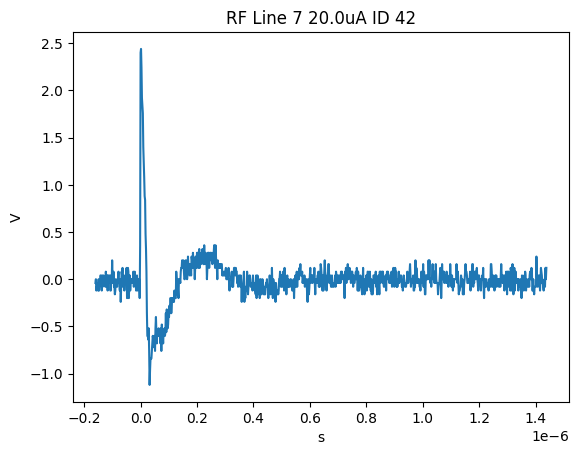

In [491]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'RF Line 7 {current*1e6}uA ID {datasaver.run_id}')
plt.xlabel('s')
plt.ylabel('V')

Starting experimental run with id: 43. 
43
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 160ns/div, 1000 points, Sample mode";1000;Y;LINEAR;"s";1.60E-9;800.0E-12;300;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

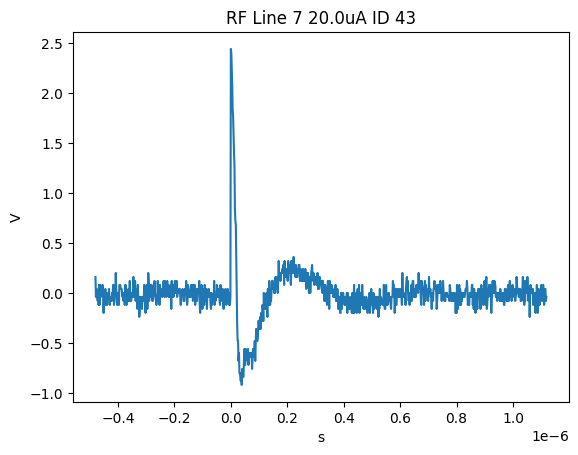

In [492]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'RF Line 7 {current*1e6}uA ID {datasaver.run_id}')
plt.xlabel('s')
plt.ylabel('V')

Setting up an RF Line 2 and hoping

In [497]:
MS.write('ACQuire:STATE 1')

Starting experimental run with id: 44. 
44
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 160ns/div, 1000 points, Sample mode";1000;Y;LINEAR;"s";1.60E-9;320.00E-12;100;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

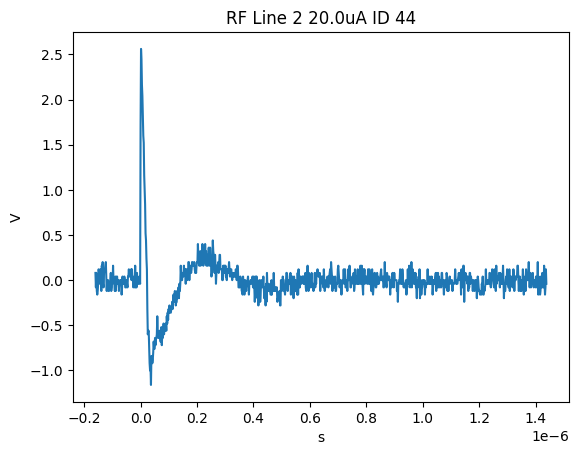

In [498]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'RF Line 2 {current*1e6}uA ID {datasaver.run_id}')
plt.xlabel('s')
plt.ylabel('V')

YAY 🎉

RF Line Critical current sweep

In [499]:
np.linspace(0, 23e-6, 4.00e-07)

array([0.00e+00, 4.00e-07, 8.00e-07, 1.20e-06, 1.60e-06, 2.00e-06,
       2.40e-06, 2.80e-06, 3.20e-06, 3.60e-06, 4.00e-06, 4.40e-06,
       4.80e-06, 5.20e-06, 5.60e-06, 6.00e-06, 6.40e-06, 6.80e-06,
       7.20e-06, 7.60e-06, 8.00e-06, 8.40e-06, 8.80e-06, 9.20e-06,
       9.60e-06, 1.00e-05, 1.04e-05, 1.08e-05, 1.12e-05, 1.16e-05,
       1.20e-05, 1.24e-05, 1.28e-05, 1.32e-05, 1.36e-05, 1.40e-05,
       1.44e-05, 1.48e-05, 1.52e-05, 1.56e-05, 1.60e-05, 1.64e-05,
       1.68e-05, 1.72e-05, 1.76e-05, 1.80e-05, 1.84e-05, 1.88e-05,
       1.92e-05, 1.96e-05, 2.00e-05])

Starting experimental run with id: 45. 
45
Ramping down
Current is 0.0


Text(0.5, 1.0, 'RF Line 2 ID 45')

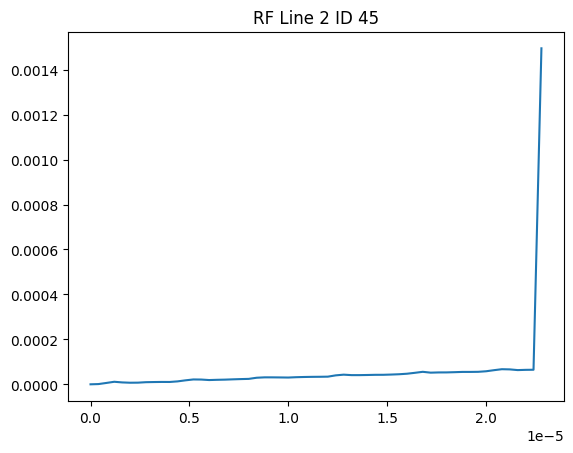

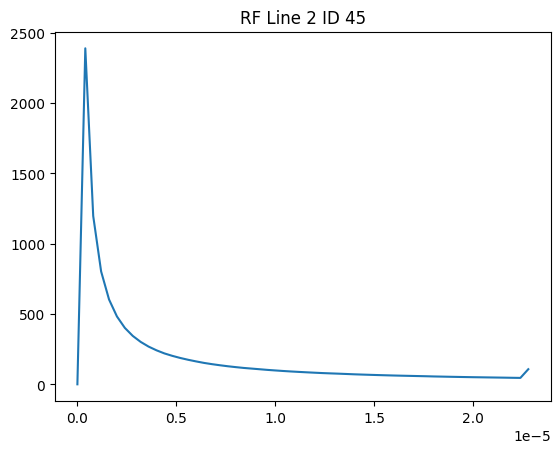

In [500]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)


currents = np.arange(0, 23e-6, 4.00e-07)

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']

plt.plot(current, voltage-voltage[0])
plt.title(f'RF Line 2 ID {datasaver.run_id}')

plt.figure()
plt.plot(current, ratio)
plt.title(f'RF Line 2 ID {datasaver.run_id}')

Text(0.5, 1.0, 'RF Line 2 ID 45')

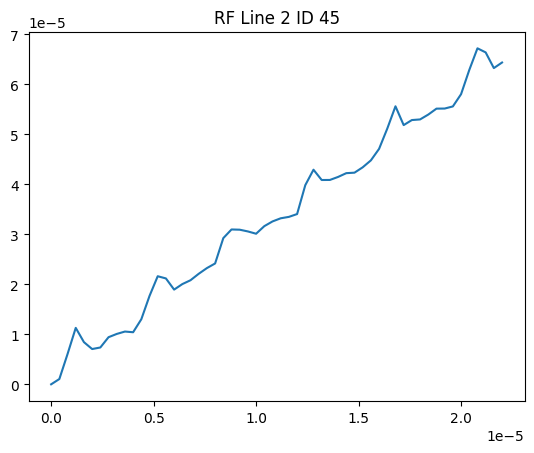

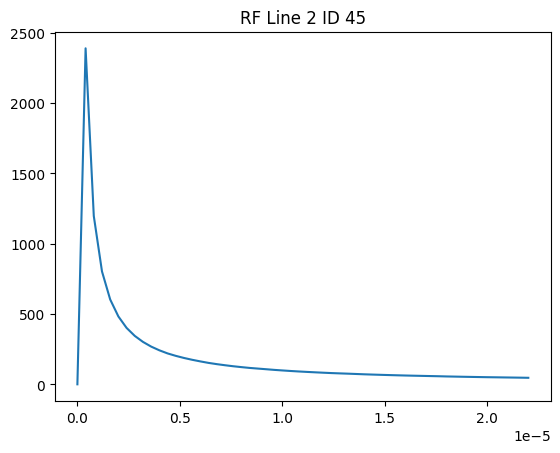

In [503]:

data = load_by_id(45).get_parameter_data()
current = data['yoko_current']['yoko_current'][:-2]
voltage = data['dmm_volt']['dmm_volt'][:-2]
ratio = data['ratio']['ratio'][:-2]

plt.plot(current, voltage-voltage[0])
plt.title(f'RF Line 2 ID {datasaver.run_id}')

plt.figure()
plt.plot(current, ratio)
plt.title(f'RF Line 2 ID {datasaver.run_id}')

Starting experimental run with id: 46. 
46
Ramping down
Current is 0.0


Text(0.5, 1.0, 'RF Line 2 ID 46')

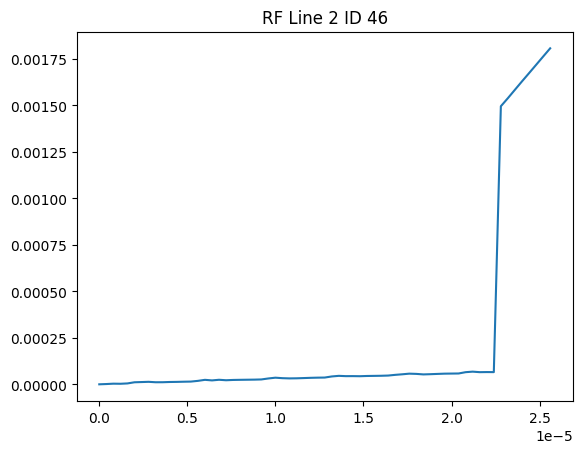

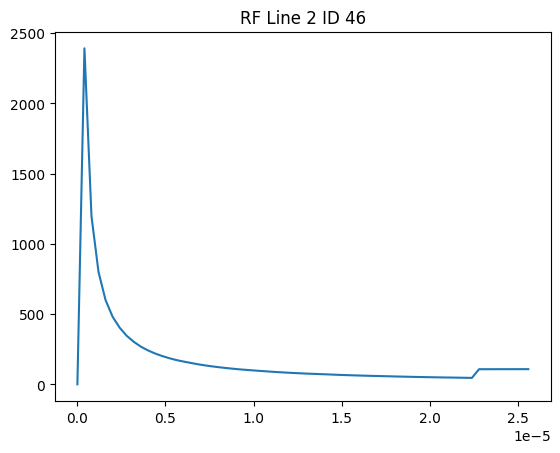

In [504]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)


currents = np.arange(0, 26e-6, 4.00e-07)

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']

plt.plot(current, voltage-voltage[0])
plt.title(f'RF Line 2 ID {datasaver.run_id}')

plt.figure()
plt.plot(current, ratio)
plt.title(f'RF Line 2 ID {datasaver.run_id}')

RF Line 7 - coming back for current sweep

Starting experimental run with id: 48. 
48
Ramping down
Current is 0.0


Text(0.5, 1.0, 'RF Line 7 ID 48')

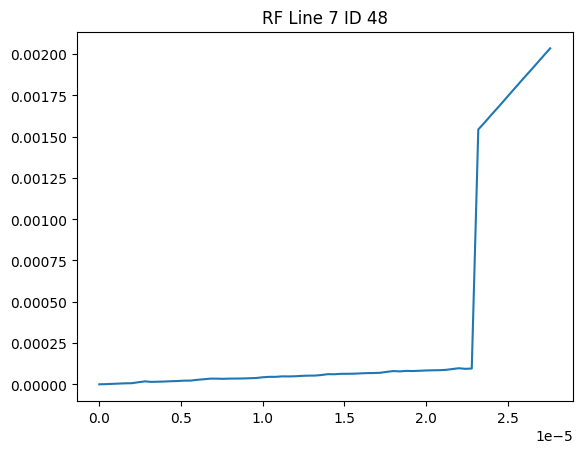

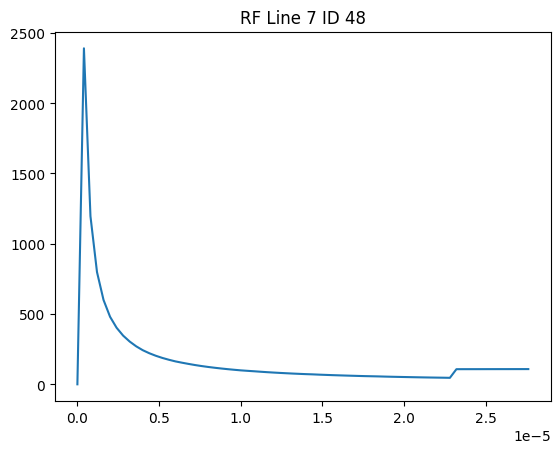

In [506]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)


currents = np.arange(0, 28e-6, 4.00e-07)

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']

plt.plot(current, voltage-voltage[0])
plt.title(f'RF Line 7 ID {datasaver.run_id}')

plt.figure()
plt.plot(current, ratio)
plt.title(f'RF Line 7 ID {datasaver.run_id}')

RF Line 12 - setting up for single count

Starting experimental run with id: 49. 
49
Ramping down
Current is 0.0


Text(0.5, 1.0, 'RF Line 12 ID 49')

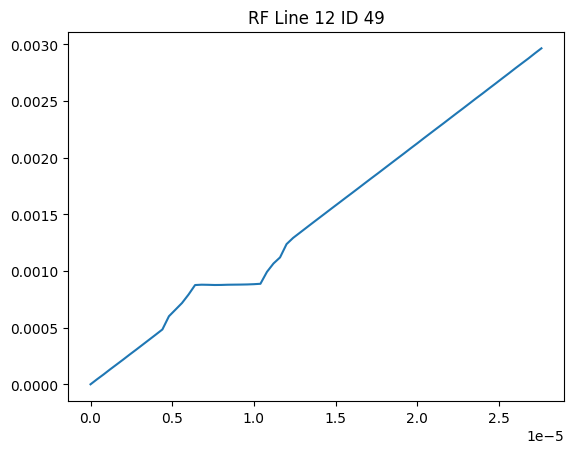

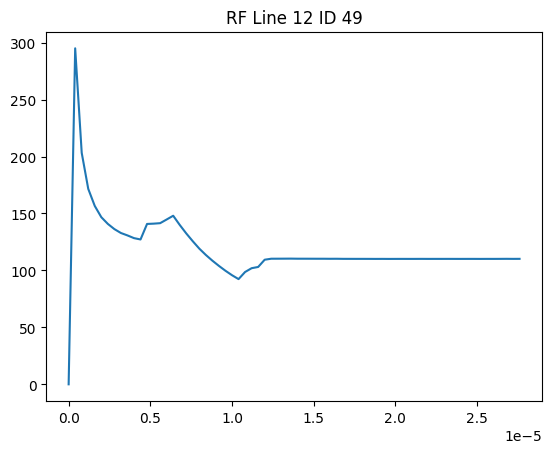

In [507]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)


currents = np.arange(0, 28e-6, 4.00e-07)

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']

plt.plot(current, voltage-voltage[0])
plt.title(f'RF Line 12 ID {datasaver.run_id}')

plt.figure()
plt.plot(current, ratio)
plt.title(f'RF Line 12 ID {datasaver.run_id}')

Will sit at 10uA based on that 

Starting experimental run with id: 50. 
50
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 160ns/div, 1000 points, Sample mode";1000;Y;LINEAR;"s";1.60E-9;640.00E-12;100;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

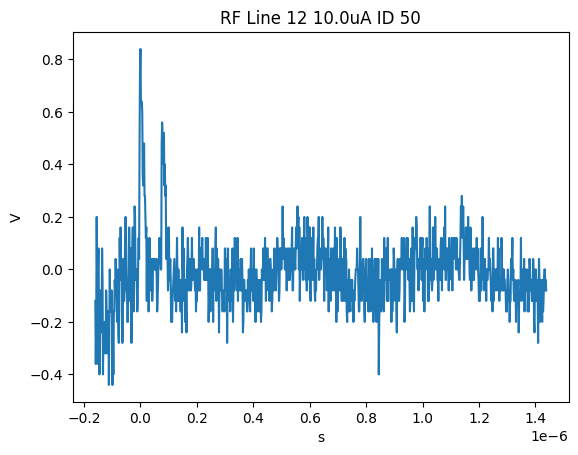

In [508]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'RF Line 12 {current*1e6}uA ID {datasaver.run_id}')
plt.xlabel('s')
plt.ylabel('V')

Starting experimental run with id: 51. 
51
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 160ns/div, 1000 points, Sample mode";1000;Y;LINEAR;"s";1.60E-9;960.00E-12;100;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

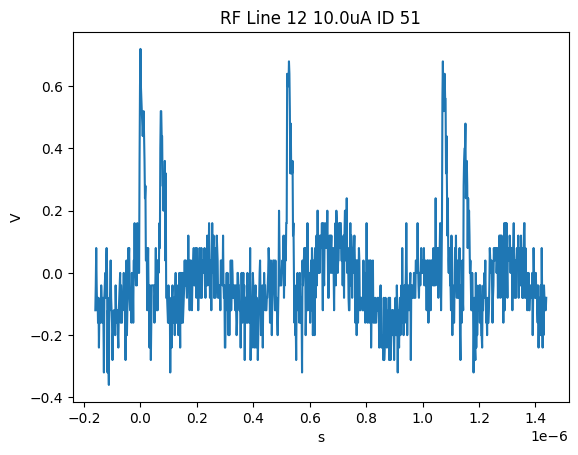

In [509]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'RF Line 12 {current*1e6}uA ID {datasaver.run_id}')
plt.xlabel('s')
plt.ylabel('V')

Starting experimental run with id: 52. 
52
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 160ns/div, 1000 points, Sample mode";1000;Y;LINEAR;"s";1.60E-9;70.0E-12;100;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

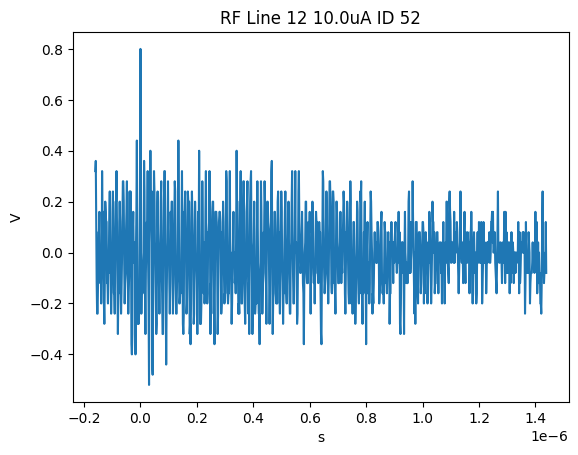

In [510]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'RF Line 12 {current*1e6}uA ID {datasaver.run_id}')
plt.xlabel('s')
plt.ylabel('V')

Starting experimental run with id: 53. 
53
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 160ns/div, 1000 points, Sample mode";1000;Y;LINEAR;"s";1.60E-9;1.60E-9;100;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

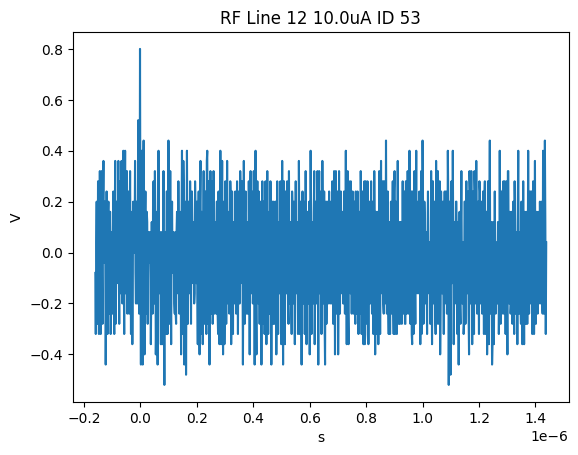

In [511]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'RF Line 12 {current*1e6}uA ID {datasaver.run_id}')
plt.xlabel('s')
plt.ylabel('V')

Regrettably forgot to do the switch line, RF line 1

Starting experimental run with id: 54. 
54
Ramping down
Current is 0.0


Text(0.5, 1.0, 'RF Line 1 S1 ID 54')

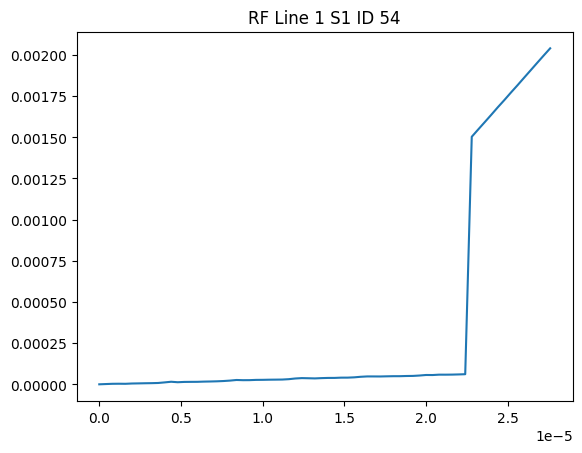

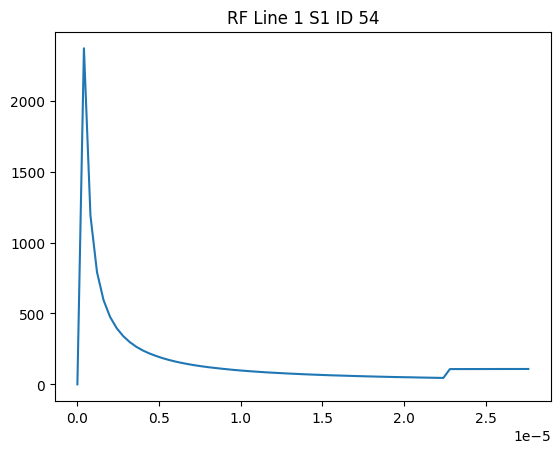

In [512]:
import numpy as np
import time

line = '1 S1'

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)


currents = np.arange(0, 28e-6, 4.00e-07)

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']

plt.plot(current, voltage-voltage[0])
plt.title(f'RF Line {line} ID {datasaver.run_id}')

plt.figure()
plt.plot(current, ratio)
plt.title(f'RF Line {line} ID {datasaver.run_id}')

Text(0.5, 1.0, 'RF Line 1 S1 ID 54')

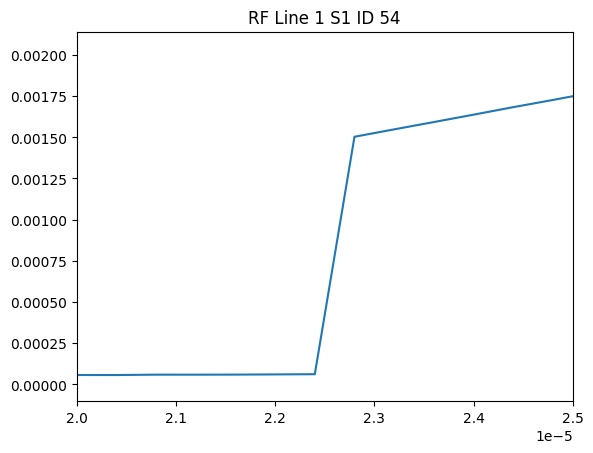

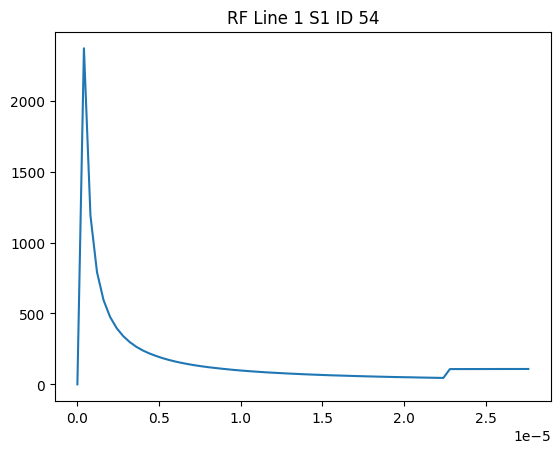

In [513]:
plt.plot(current, voltage-voltage[0])
plt.title(f'RF Line {line} ID {datasaver.run_id}')
plt.xlim([20e-6, 25e-6])

plt.figure()
plt.plot(current, ratio)
plt.title(f'RF Line {line} ID {datasaver.run_id}')

In [514]:
yoko.current(22e-6)

Starting experimental run with id: 55. 
55
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 160ns/div, 1000 points, Sample mode";1000;Y;LINEAR;"s";1.60E-9;1.1050E-9;100;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

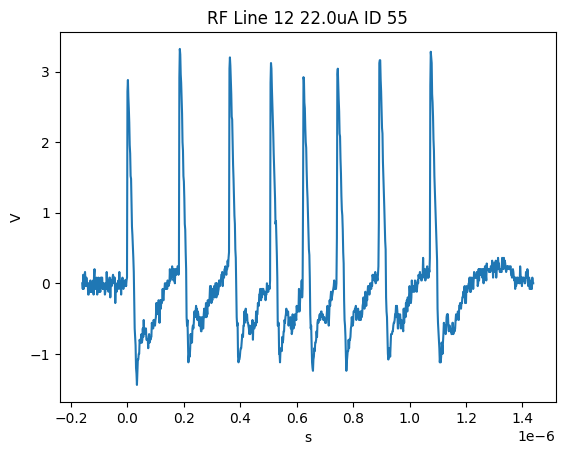

In [515]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'RF Line 12 {current*1e6}uA ID {datasaver.run_id}')
plt.xlabel('s')
plt.ylabel('V')

Text(0, 0.5, 'V')

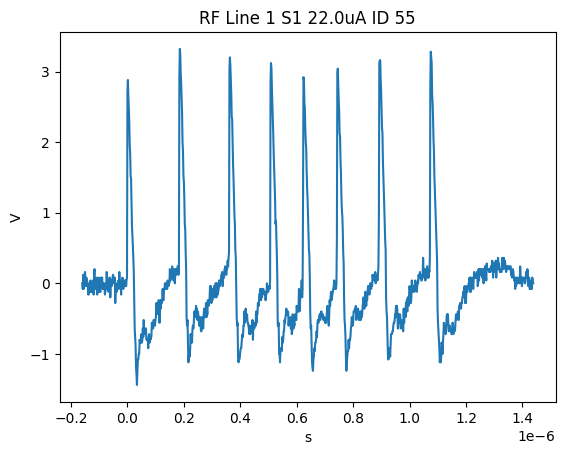

In [517]:
data = load_by_id(55).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'RF Line 1 S1 {current*1e6}uA ID {55}')
plt.xlabel('s')
plt.ylabel('V')

Starting experimental run with id: 56. 
56
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 160ns/div, 1000 points, Sample mode";1000;Y;LINEAR;"s";1.60E-9;825.000E-12;100;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

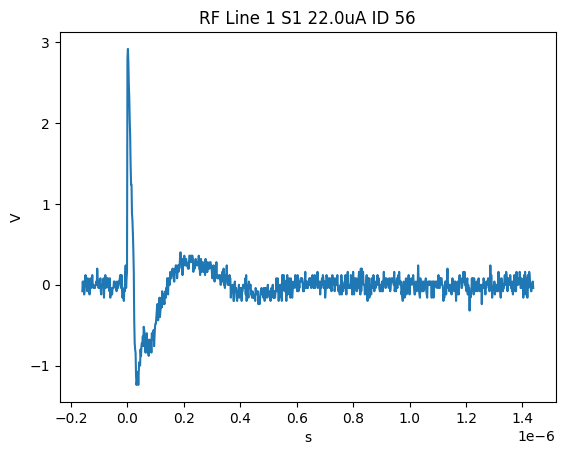

In [518]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'RF Line 1 S1 {current*1e6}uA ID {datasaver.run_id}')
plt.xlabel('s')
plt.ylabel('V')

Starting experimental run with id: 57. 
57
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 160ns/div, 1000 points, Sample mode";1000;Y;LINEAR;"s";1.60E-9;34.9999999999909E-12;100;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

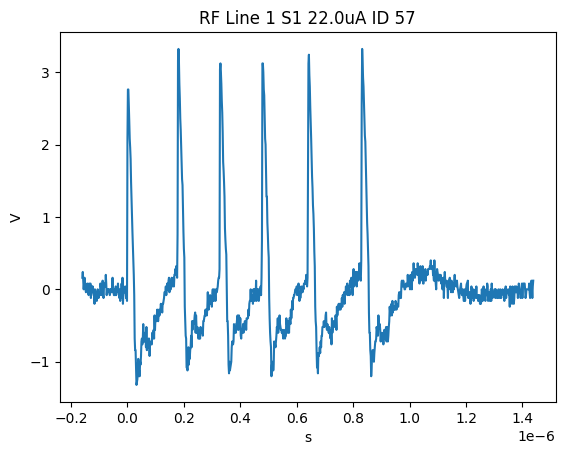

In [519]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'RF Line 1 S1 {current*1e6}uA ID {datasaver.run_id}')
plt.xlabel('s')
plt.ylabel('V')

In [ ]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'RF Line 1 S1 {current*1e6}uA ID {datasaver.run_id}')
plt.xlabel('s')
plt.ylabel('V')

# 10/3/26 Export Data

Text(0, 0.5, 'V')

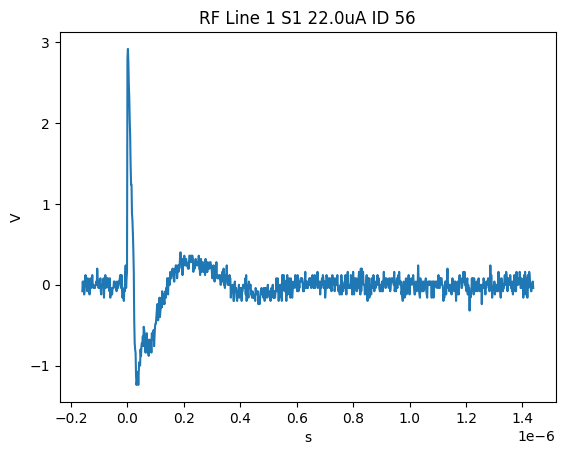

In [10]:
ID_num = 56
data = load_by_id(56).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'RF Line 1 S1 {current*1e6}uA ID {ID_num}')
plt.xlabel('s')
plt.ylabel('V')

In [11]:
import pandas as pd

# Sample DataFrame
SNSPD2_trace_ID56 = {'trace': trace, 'time_axis': time_axis, 'current': current}
df = pd.DataFrame(SNSPD2_trace_ID56)

# Export to a CSV file named 'output_file.csv'
df.to_csv('SNSPD2_trace_ID56.csv')

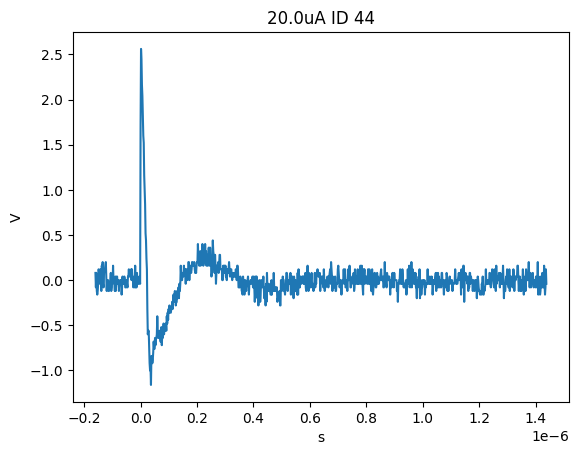

In [13]:
ID_num = 44
data = load_by_id(ID_num).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'{current*1e6}uA ID {ID_num}')
plt.xlabel('s')
plt.ylabel('V')

# Sample DataFrame
SNSPD2_trace_ID44 = {'trace': trace, 'time_axis': time_axis, 'current': current}
df = pd.DataFrame(SNSPD2_trace_ID44)

# Export to a CSV file named 'output_file.csv'
df.to_csv('SNSPD2_trace_ID44.csv')

RF Line 7 is IDs 38-43 

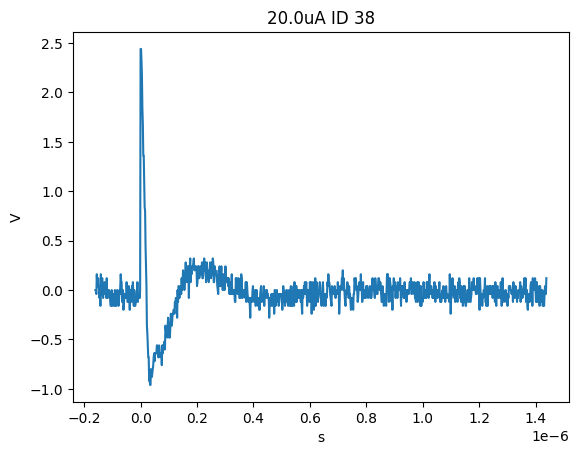

In [15]:
ID_num = 38
data = load_by_id(ID_num).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'{current*1e6}uA ID {ID_num}')
plt.xlabel('s')
plt.ylabel('V')

# Sample DataFrame
SNSPD2_trace_ID38 = {'trace': trace, 'time_axis': time_axis, 'current': current}
df = pd.DataFrame(SNSPD2_trace_ID38)

# Export to a CSV file named 'output_file.csv'
df.to_csv('SNSPD2_trace_ID38.csv')

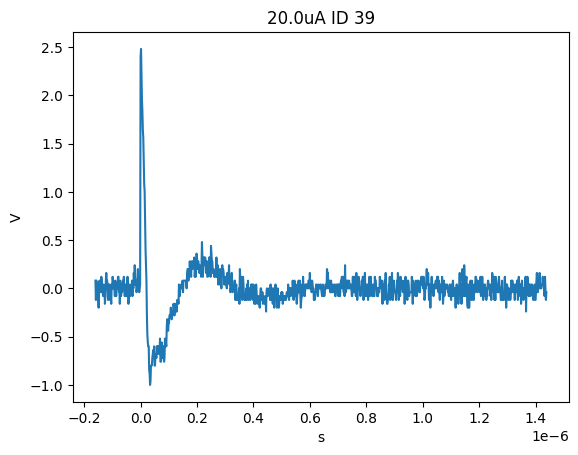

In [16]:
ID_num = 39
data = load_by_id(ID_num).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'{current*1e6}uA ID {ID_num}')
plt.xlabel('s')
plt.ylabel('V')

# Sample DataFrame
SNSPD2_trace_ID39 = {'trace': trace, 'time_axis': time_axis, 'current': current}
df = pd.DataFrame(SNSPD2_trace_ID39)

# Export to a CSV file named 'output_file.csv'
df.to_csv('SNSPD2_trace_ID39.csv')

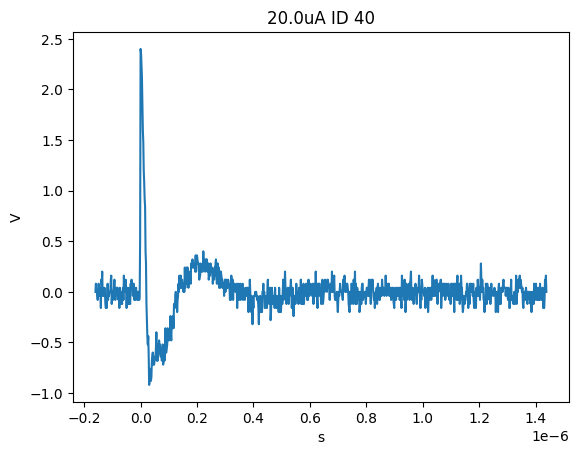

In [17]:
ID_num = 40
data = load_by_id(ID_num).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'{current*1e6}uA ID {ID_num}')
plt.xlabel('s')
plt.ylabel('V')

# Sample DataFrame
SNSPD2_trace_ID40 = {'trace': trace, 'time_axis': time_axis, 'current': current}
df = pd.DataFrame(SNSPD2_trace_ID40)

# Export to a CSV file named 'output_file.csv'
df.to_csv('SNSPD2_trace_ID40.csv')

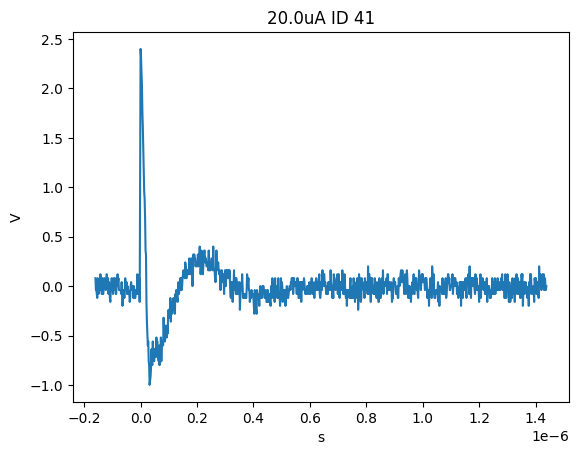

In [18]:
ID_num = 41
data = load_by_id(ID_num).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'{current*1e6}uA ID {ID_num}')
plt.xlabel('s')
plt.ylabel('V')

# Sample DataFrame
SNSPD2_trace_ID41 = {'trace': trace, 'time_axis': time_axis, 'current': current}
df = pd.DataFrame(SNSPD2_trace_ID41)

# Export to a CSV file named 'output_file.csv'
df.to_csv('SNSPD2_trace_ID41.csv')

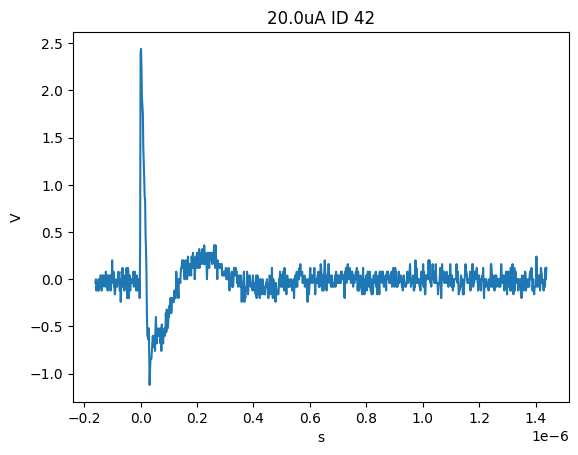

In [19]:
ID_num = 42
data = load_by_id(ID_num).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']


plt.plot(time_axis, trace)
plt.title(f'{current*1e6}uA ID {ID_num}')
plt.xlabel('s')
plt.ylabel('V')

# Sample DataFrame
SNSPD2_trace_ID42 = {'trace': trace, 'time_axis': time_axis, 'current': current}
df = pd.DataFrame(SNSPD2_trace_ID42)

# Export to a CSV file named 'output_file.csv'
df.to_csv('SNSPD2_trace_ID42.csv')